In [8]:
using LinearAlgebra
using Distributions
using LaTeXStrings
using Printf
using FileIO
import JLD2

In [60]:
using Symbolics
using LinearAlgebra

# Define symbolic parameters
@variables a b r
@variables i j

"""
    construct_symbolic_matrix(N, a, b, r)

Construct an N×N symbolic matrix where diagonal elements are a√(2i+r)√(2j+r)
and off-diagonal elements are b√(2i+r)√(2j+r).

Parameters (symbolic):
- a: coefficient for diagonal elements
- b: coefficient for off-diagonal elements  
- r: parameter in the square root terms
- N: matrix dimension (must be numeric)
"""
function construct_symbolic_matrix(N::Int, a, b, r)
    M = zeros(Num, N, N)
    
    for i in 1:N
        for j in 1:N
            coeff = sqrt(2i + r)  sqrt(2j + r)
            if i == j
                M[i, j] = a  coeff
            else
                M[i, j] = b  coeff
            end
        end
    end
    
    return M
end

# Construct the matrix with symbolic parameters
N = 10
M_symbolic = construct_symbolic_matrix(N, a, b, r)

println("Symbolic Matrix M (first 4×4 block):")
println(M_symbolic[1:4, 1:4])
println("\nFull symbolic matrix dimensions: $(size(M_symbolic))")

# Display some entries to show the structure
println("\nDiagonal entry M[1,1] = ", M_symbolic[1, 1])
println("Off-diagonal entry M[1,2] = ", M_symbolic[1, 2])
println("Diagonal entry M[2,2] = ", M_symbolic[2, 2])

LoadError: ParseError:
[90m# Error @ [0;0m]8;;file:///home/sofialon/Newtrinos.jl/notebooks/In[60]#25:35\[90mIn[60]:25:35[0;0m]8;;\
        for j in 1:N
            coeff = sqrt(2i + r)  [48;2;120;70;70msqrt(2j + r[0;0m)
[90m#                                 └─────────┘ ── [0;0m[91mExpected `end`[0;0m

In [ ]:
using Symbolics
using LinearAlgebra

# Define symbolic parameters
@variables a b r λ

"""
    construct_symbolic_matrix(N, a, b, r)

Construct an N×N symbolic matrix.
"""
function construct_symbolic_matrix(N::Int, a, b, r)
    M = zeros(Num, N, N)
    
    for i in 1:N
        for j in 1:N
            coeff = sqrt(2i + r) *sqrt(2j + r)
            if i == j
                M[i, j] = a * coeff
            else
                M[i, j] = b * coeff
            end
        end
    end
    
    return M
end


N = 2
M = construct_symbolic_matrix(N, a, b, r)

println("\nMatrix M:")
for i in 1:N
    println(M[i, :])
end


I_sym = Num.(Matrix(I, N, N))
char_matrix = M .- λ * I_sym
char_poly = det(char_matrix)

println("\nCharacteristic polynomial (unsimplified):")
println(char_poly)

# Simplify
char_poly_simplified = simplify(char_poly)
println("\nCharacteristic polynomial (simplified):")
println(char_poly_simplified)



try
    eigenvalues = solve(char_poly_simplified, λ)
    println("\n✓ Eigenvalues found!\n")
    for (i, eig) in enumerate(eigenvalues)
        println("λ[$i] = ")
        display(eig)
        println()
    end
catch e
    println("\n✗ Error solving: $e")
    println("\nCharacteristic polynomial to solve:")
    println(char_poly_simplified, " = 0")
end


N = 3
M = construct_symbolic_matrix(N, a, b, r)

println("\nMatrix M:")
for i in 1:N
    println(M[i, :])
end

println("\nComputing characteristic polynomial...")
I_sym = Num.(Matrix(I, N, N))
char_matrix = M .- λ * I_sym
char_poly = det(char_matrix)
char_poly_simplified = simplify(char_poly)

println("\nCharacteristic polynomial (simplified):")
println(char_poly_simplified)

try
    println("\nAttempting to solve for eigenvalues...")
    eigenvalues = solve(char_poly_simplified, λ)
    println("\n✓ Eigenvalues found!")
    for (i, eig) in enumerate(eigenvalues)
        println("λ[$i] = ", eig)
    end
catch e
    println("\n✗ Cannot solve symbolically: $e")
    println("(This is expected for cubic and higher degree polynomials)")
end


Matrix M:
Num[a*(sqrt(2 + r)^2), b*sqrt(4 + r)*sqrt(2 + r)]
Num[b*sqrt(4 + r)*sqrt(2 + r), a*(sqrt(4 + r)^2)]

Characteristic polynomial (unsimplified):
(-λ + a*(sqrt(4 + r)^2))*(-λ + a*(sqrt(2 + r)^2)) - (b^2)*(sqrt(4 + r)^2)*(sqrt(2 + r)^2)

Characteristic polynomial (simplified):
(-λ + a*(sqrt(4 + r)^2))*(-λ + a*(sqrt(2 + r)^2)) - (b^2)*(sqrt(4 + r)^2)*(sqrt(2 + r)^2)

✗ Error solving: UndefVarError(:solve, Main)

Characteristic polynomial to solve:
(-λ + a*(sqrt(4 + r)^2))*(-λ + a*(sqrt(2 + r)^2)) - (b^2)*(sqrt(4 + r)^2)*(sqrt(2 + r)^2) = 0

Matrix M:
Num[a*(sqrt(2 + r)^2), b*sqrt(4 + r)*sqrt(2 + r), b*sqrt(6 + r)*sqrt(2 + r)]
Num[b*sqrt(4 + r)*sqrt(2 + r), a*(sqrt(4 + r)^2), b*sqrt(6 + r)*sqrt(4 + r)]
Num[b*sqrt(6 + r)*sqrt(2 + r), b*sqrt(6 + r)*sqrt(4 + r), a*(sqrt(6 + r)^2)]

Computing characteristic polynomial...

Characteristic polynomial (simplified):
((-λ + a*(sqrt(6 + r)^2))*(-λ + a*(sqrt(4 + r)^2)) - (b^2)*(sqrt(6 + r)^2)*(sqrt(4 + r)^2))*(-λ + a*(sqrt(2 + r)^2)) + ((λ - 

In [ ]:
(1000000000000+1)^(0.000001)

1.000027631402856

In [ ]:

N_values=LinRange(1,100,100)
gamma_values=LinRange(1,100,100)

result=zeros(Float64, 100, 100)

for i in 1:100
    for j in 1:100

        if ((i/(i-1))^(j))-(1+(j/(i-1)))<1e-5
             
            result[i,j]=1
        else
          
            result[i,j]=0
        end

    end
    
end    



display(result)

100×100 Matrix{Float64}:
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0

Test for scaling of eta

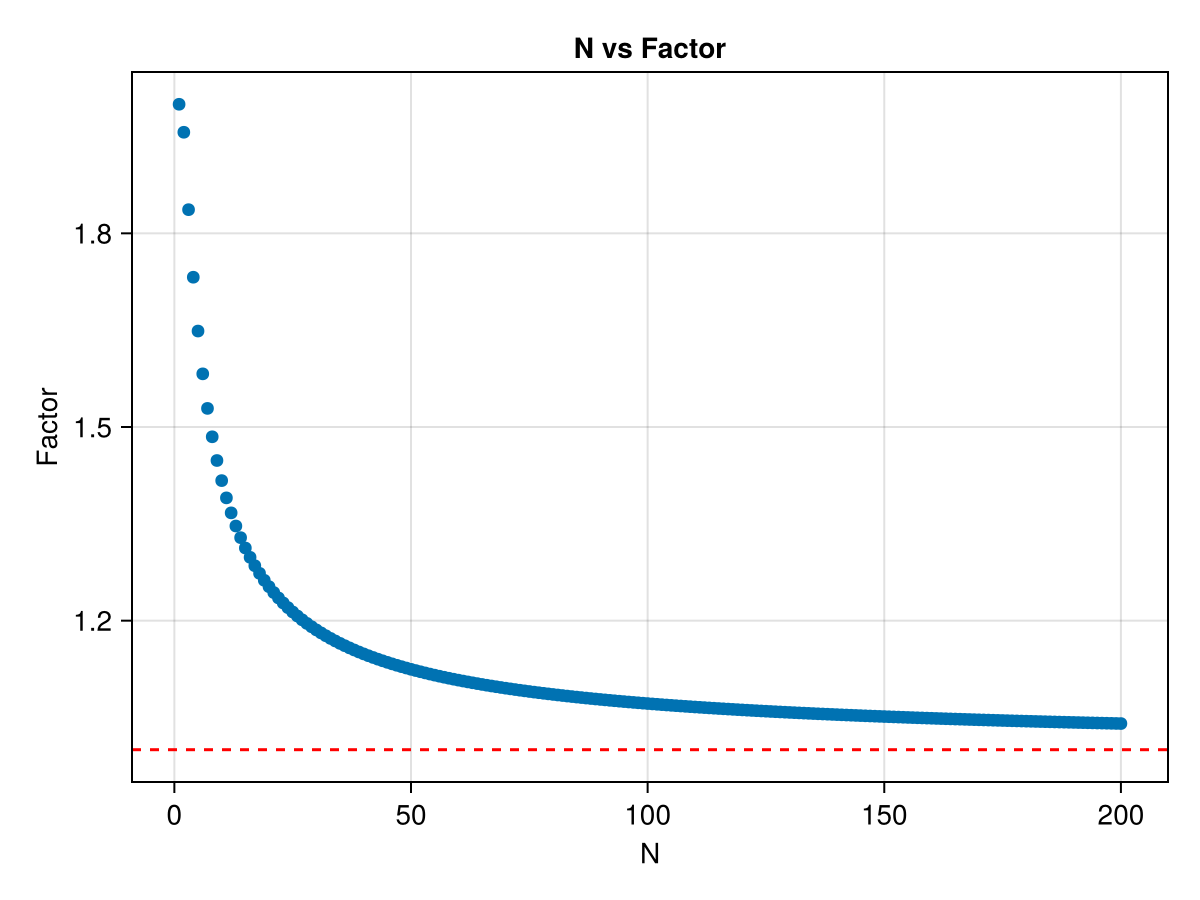

In [ ]:
using CairoMakie

N_values=LinRange(1,200,200)

factors=zeros(Float64, 200)

for (i, n) in enumerate(N_values)
    factors[i] = (1+n*n)^(1/n)
end


fig = Figure()
ax = Axis(fig[1, 1], xlabel="N", ylabel="Factor", title="N vs Factor")
scatter!(ax, N_values, factors)
hlines!(ax, 1, color=:red, linestyle=:dash, label="1")
fig

Trial for eigenvalue expression

In [ ]:
N=100
r= 0

B=1 #B=b^2
A=1.1
#A=(1+1/N)*B      #A=a^2


1.1

In [ ]:
eigen=[]
det_analytical=1.0
for i in 1:N
    eigenvalue =(2)^(1/(N-1))*(A-B)*(2i + r)

    if i==N
       eigenvalue =(1/2)*(1+B*N/(A-B))*(A-B)*(2i + r)
    end

    det_analytical*=eigenvalue
    push!(eigen, eigenvalue)
end
display(det_analytical)
display(eigen[N])
display(eigen)

1.1842333805758106e91

10010.0

100-element Vector{Any}:
     0.2014052108767
     0.4028104217534
     0.6042156326301
     0.8056208435068
     1.0070260543835
     1.2084312652602
     1.4098364761369
     1.6112416870136
     1.8126468978902999
     2.014052108767
     2.2154573196436997
     2.4168625305204
     2.6182677413971
     ⋮
    17.9250637680263
    18.126468978903
    18.3278741897797
    18.5292794006564
    18.7306846115331
    18.9320898224098
    19.1334950332865
    19.3349002441632
    19.536305455039898
    19.737710665916598
    19.9391158767933
 10010.0

In [ ]:
M = zeros(Float64, N, N)
    
    for i in 1:N
        for j in 1:N
            coeff = sqrt(2i + r) *sqrt(2j + r)
            if i == j
                M[i, j] = (A/B) * coeff
            else
                M[i, j] =coeff
            end
        end
    end

eigenvalues_real = eigvals(Matrix(B*M))    

determinant_real = (det(Matrix(B*M)))


1.1842333805758124e91

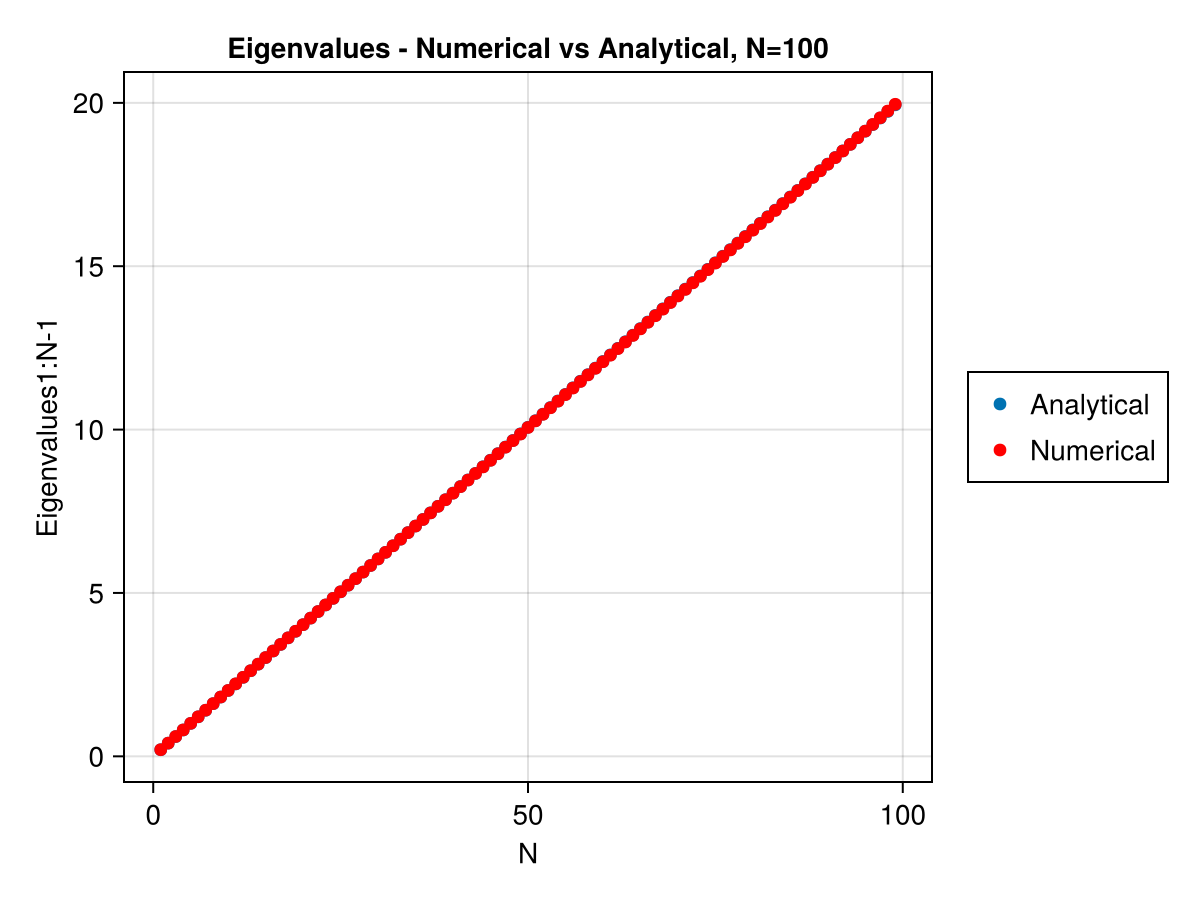

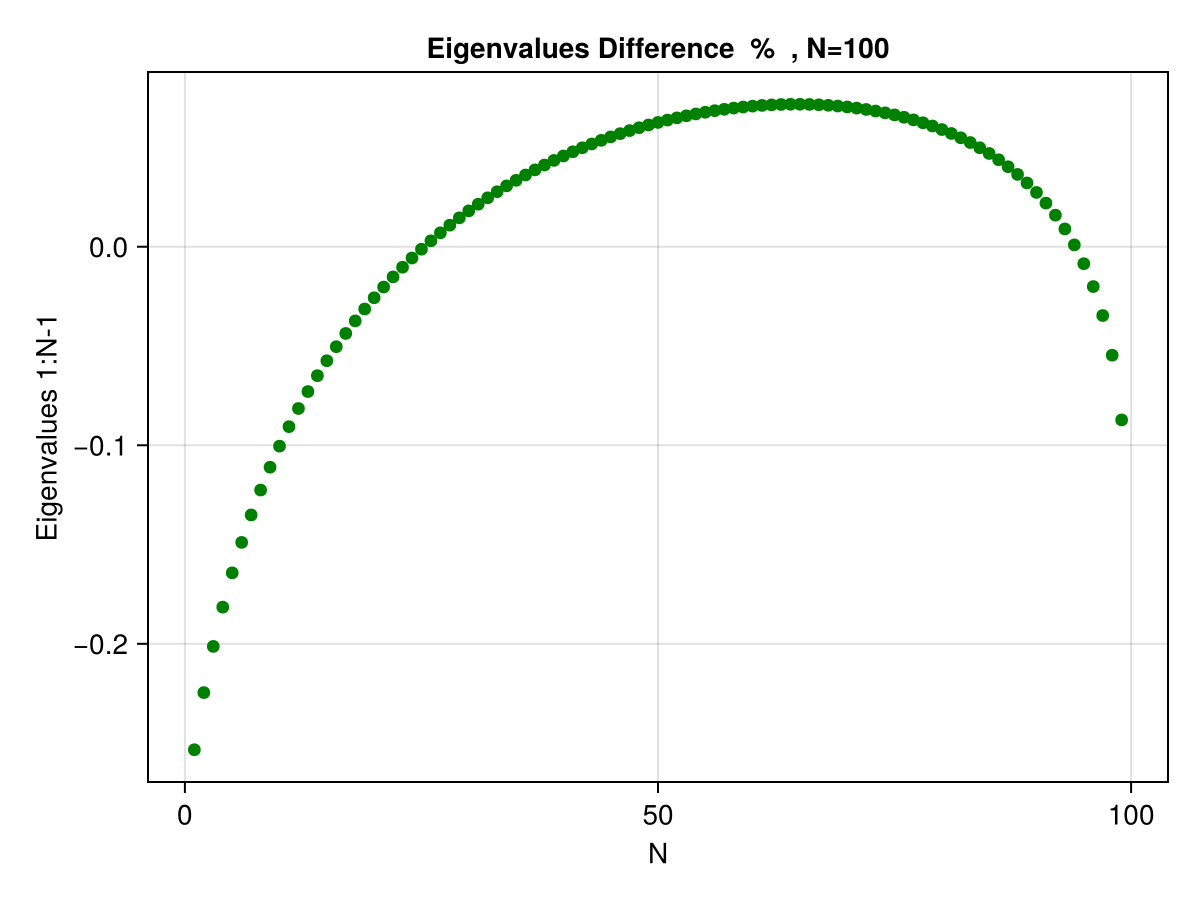

CairoMakie.Screen{IMAGE}


In [ ]:
using CairoMakie

N_values=LinRange(1,N,N)


fig = Figure()
ax = Axis(fig[1, 1], xlabel="N", ylabel="Eigenvalues1:N-1", title="Eigenvalues - Numerical vs Analytical, N=$N")
scatter!(ax, N_values[1:N-1], eigen[1:N-1], label="Analytical")
scatter!(ax, N_values[1:N-1], eigenvalues_real[1:N-1], color=:red, label="Numerical")

Legend(fig[1, 2], ax)
#save("/home/sofialon/Newtrinos.jl/plots_NP/eigenvalues_comp_N$(N).png", fig)
display(fig)



fig1 = Figure()
ax = Axis(fig1[1, 1], xlabel="N", ylabel="Eigenvalues 1:N-1", title="Eigenvalues Difference  %  , N=$N")
scatter!(ax, N_values[1:N-1], 100*(eigen[1:N-1].-eigenvalues_real[1:N-1])./eigenvalues_real[1:N-1], color=:green, label="Numerical- Analytical")
        #save("/home/sofialon/Newtrinos.jl/plots_NP/eigenvalues_res_N$(N).png", fig)
 display(fig1)

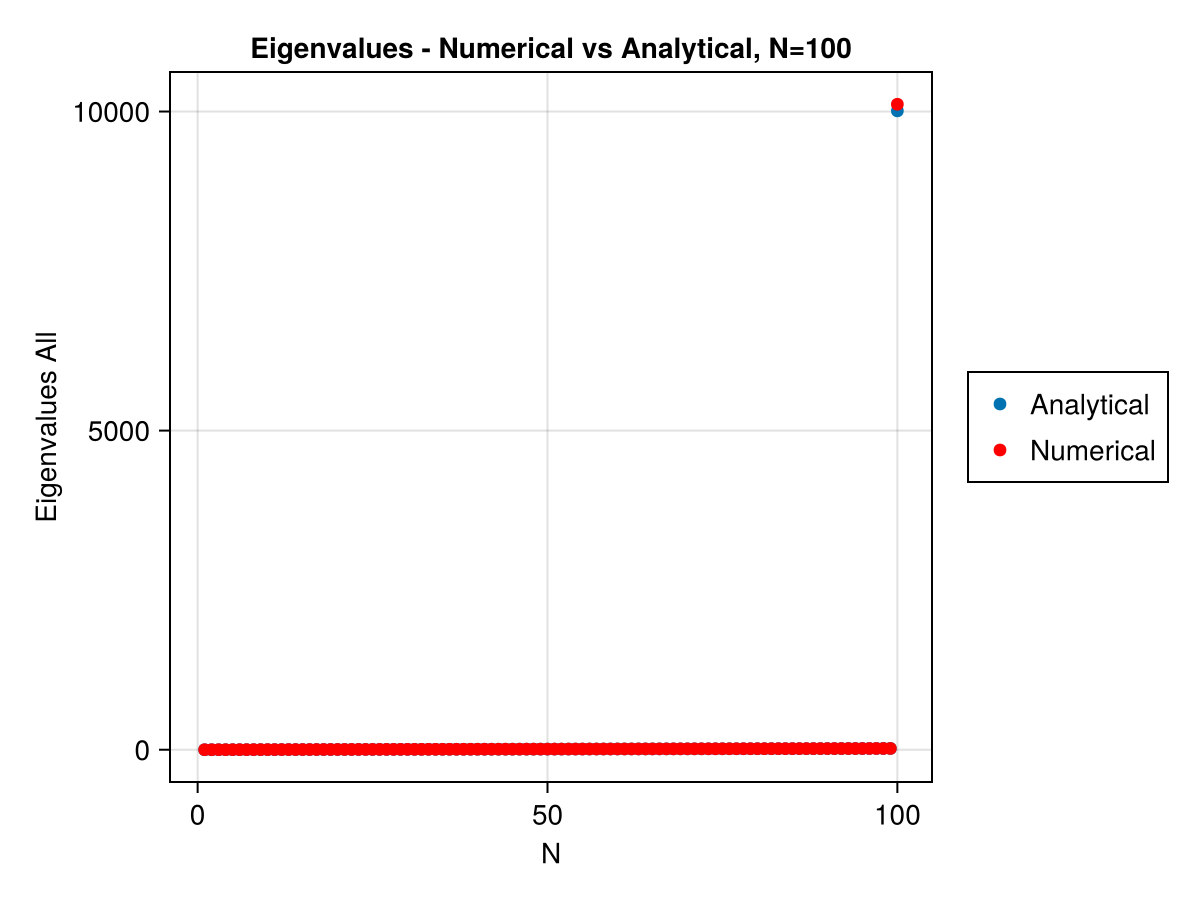

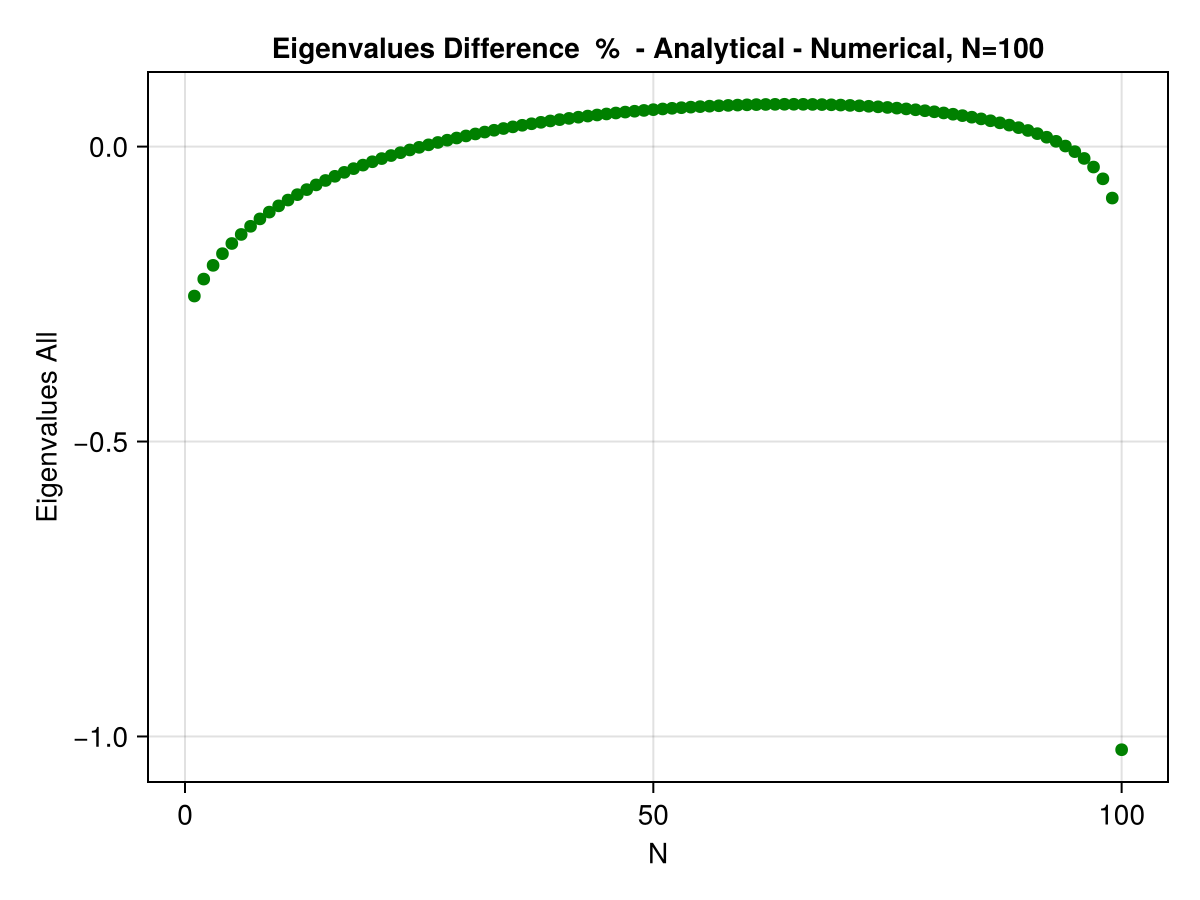

CairoMakie.Screen{IMAGE}


In [ ]:


fig = Figure()
ax = Axis(fig[1, 1], xlabel="N", ylabel="Eigenvalues All", title="Eigenvalues - Numerical vs Analytical, N=$N")
scatter!(ax, N_values, eigen, label="Analytical")
scatter!(ax, N_values, eigenvalues_real, color=:red, label="Numerical")

Legend(fig[1, 2], ax)
#save("/home/sofialon/Newtrinos.jl/plots_NP/eigenvalues_comp_N$(N)_N.png", fig)
display(fig)



fig1 = Figure()
ax = Axis(fig1[1, 1], xlabel="N", ylabel="Eigenvalues All", title="Eigenvalues Difference  %  - Analytical - Numerical, N=$N")
scatter!(ax, N_values, 100*(eigen.-eigenvalues_real)./eigenvalues_real, color=:green, label="Numerical- Analytical")
#save("/home/sofialon/Newtrinos.jl/plots_NP/eigenvalues_res_N$(N)_N.png", fig1)
display(fig1)

Comparison eigenvalues perturbation-full


In [122]:
using DataFrames
using Revise
using Newtrinos
using Newtrinos.osc

In [123]:
osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NND(three_flavour=Newtrinos.osc.ThreeFlavour(ordering=:NO)),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

Newtrinos.osc.Osc(OscillationConfig{NND, SI, Basic, Newtrinos.osc.All}(NND(ThreeFlavour(:NO)), SI(), Basic(), Newtrinos.osc.All()), (m₀ = 0.01, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761, δCP = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, N = 100.0, r = 1.0, η = 99.0), (m₀ = LogUniform{Float64}(a=1.0e-6, b=0.1), θ₁₂ = Uniform{Float64}(a=0.4205343352839651, b=0.7853981633974483), θ₁₃ = Uniform{Float64}(a=0.1, b=0.2), θ₂₃ = Uniform{Float64}(a=0.5235987755982988, b=1.0471975511965976), δCP = Uniform{Float64}(a=0.0, b=6.283185307179586), Δm²₂₁ = Uniform{Float64}(a=6.5e-5, b=9.0e-5), Δm²₃₁ = Uniform{Float64}(a=0.002, b=0.003), N = DiscreteUniform(a=2, b=40), r = Uniform{Float64}(a=1.0e-8, b=1.0), η = Uniform{Float64}(a=1.01, b=100.0)), Newtrinos.osc.var"#get_Nnaturalness#54"(), Newtrinos.osc.var"#osc_prob#43"{Newtrinos.osc.var"#osc_prob#41#44"{OscillationConfig{NND, SI, Basic, Newtrinos.osc.All}}}(Newtrinos.osc.var"#osc_prob#41#44"{OscillationConfig

In [124]:

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics = (; osc, atm_flux, earth_layers);

In [125]:
experiments = (
 
    dayabay = Newtrinos.dayabay.configure(physics),
);

[ Info: Loading dayabay data


In [126]:
par = Newtrinos.get_params(experiments)
p=merge(par, (r=0.5,))

(N = 100.0, m₀ = 0.01, r = 0.5, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, η = 99.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [127]:
N=p.N
m0=p.m₀
r=p.r


0.5

In [128]:
f1 = Newtrinos.osc.get_matrices(osc_cfg.flavour)
FinalUmatrix, h, eigenvalues = f1(p)

file_name_eigen="/home/sofialon/Newtrinos.jl/plots_NP/pert_full/eigenvalues_full_NND_ NO_$N $r $m0.txt"

open(file_name_eigen, "w") do io
    for i in 1:length(eigenvalues)
        @printf(io, "%f\n", eigenvalues[i])
    end
end 

file_name_h="/home/sofialon/Newtrinos.jl/plots_NP/pert_full/h_full_NND_ NO_$N $r $m0.txt"

open(file_name_h, "w") do io
    for i in 1:length(h)
        @printf(io, "%f\n", h[i])
    end
end 


In [129]:
#analytical eigenvalues
m1,m2,m3=Newtrinos.osc.get_abs_masses(p)

eigen_analytical=[]



for i in 1:N
    eigenvalue_e =(2(i-1) + r)*m1^2/r

    eigenvalue_mu=(2(i-1) + r)*m2^2/r

    eigenvalue_t =(2(i-1) + r)*m3^2/r
    push!(eigen_analytical, eigenvalue_e)
    push!(eigen_analytical, eigenvalue_mu)
    push!(eigen_analytical, eigenvalue_t)
end
#eigen_analytical=sort(eigen_analytical)    
eigen_analytical[1]=m1^2
eigen_analytical[2]=m2^2
eigen_analytical[3]=m3^2


0.002575299999999999

In [130]:
#analytical h


h_analytical=[]

for i in 1:N
    h_e =(2(i-1) + r)*m1^2/r -m1^2

    h_mu=(2(i-1) + r)*m2^2/r  -m1^2

    h_t =(2(i-1) + r)*m3^2/r  -m1^2
    push!(h_analytical, h_e)
    push!(h_analytical, h_mu)
    push!(h_analytical, h_t)
end
#h_analytical=sort(h_analytical)    
h_analytical[1]=0
h_analytical[2]=p.Δm²₂₁
h_analytical[3]=p.Δm²₃₁

0.0024752999999999997

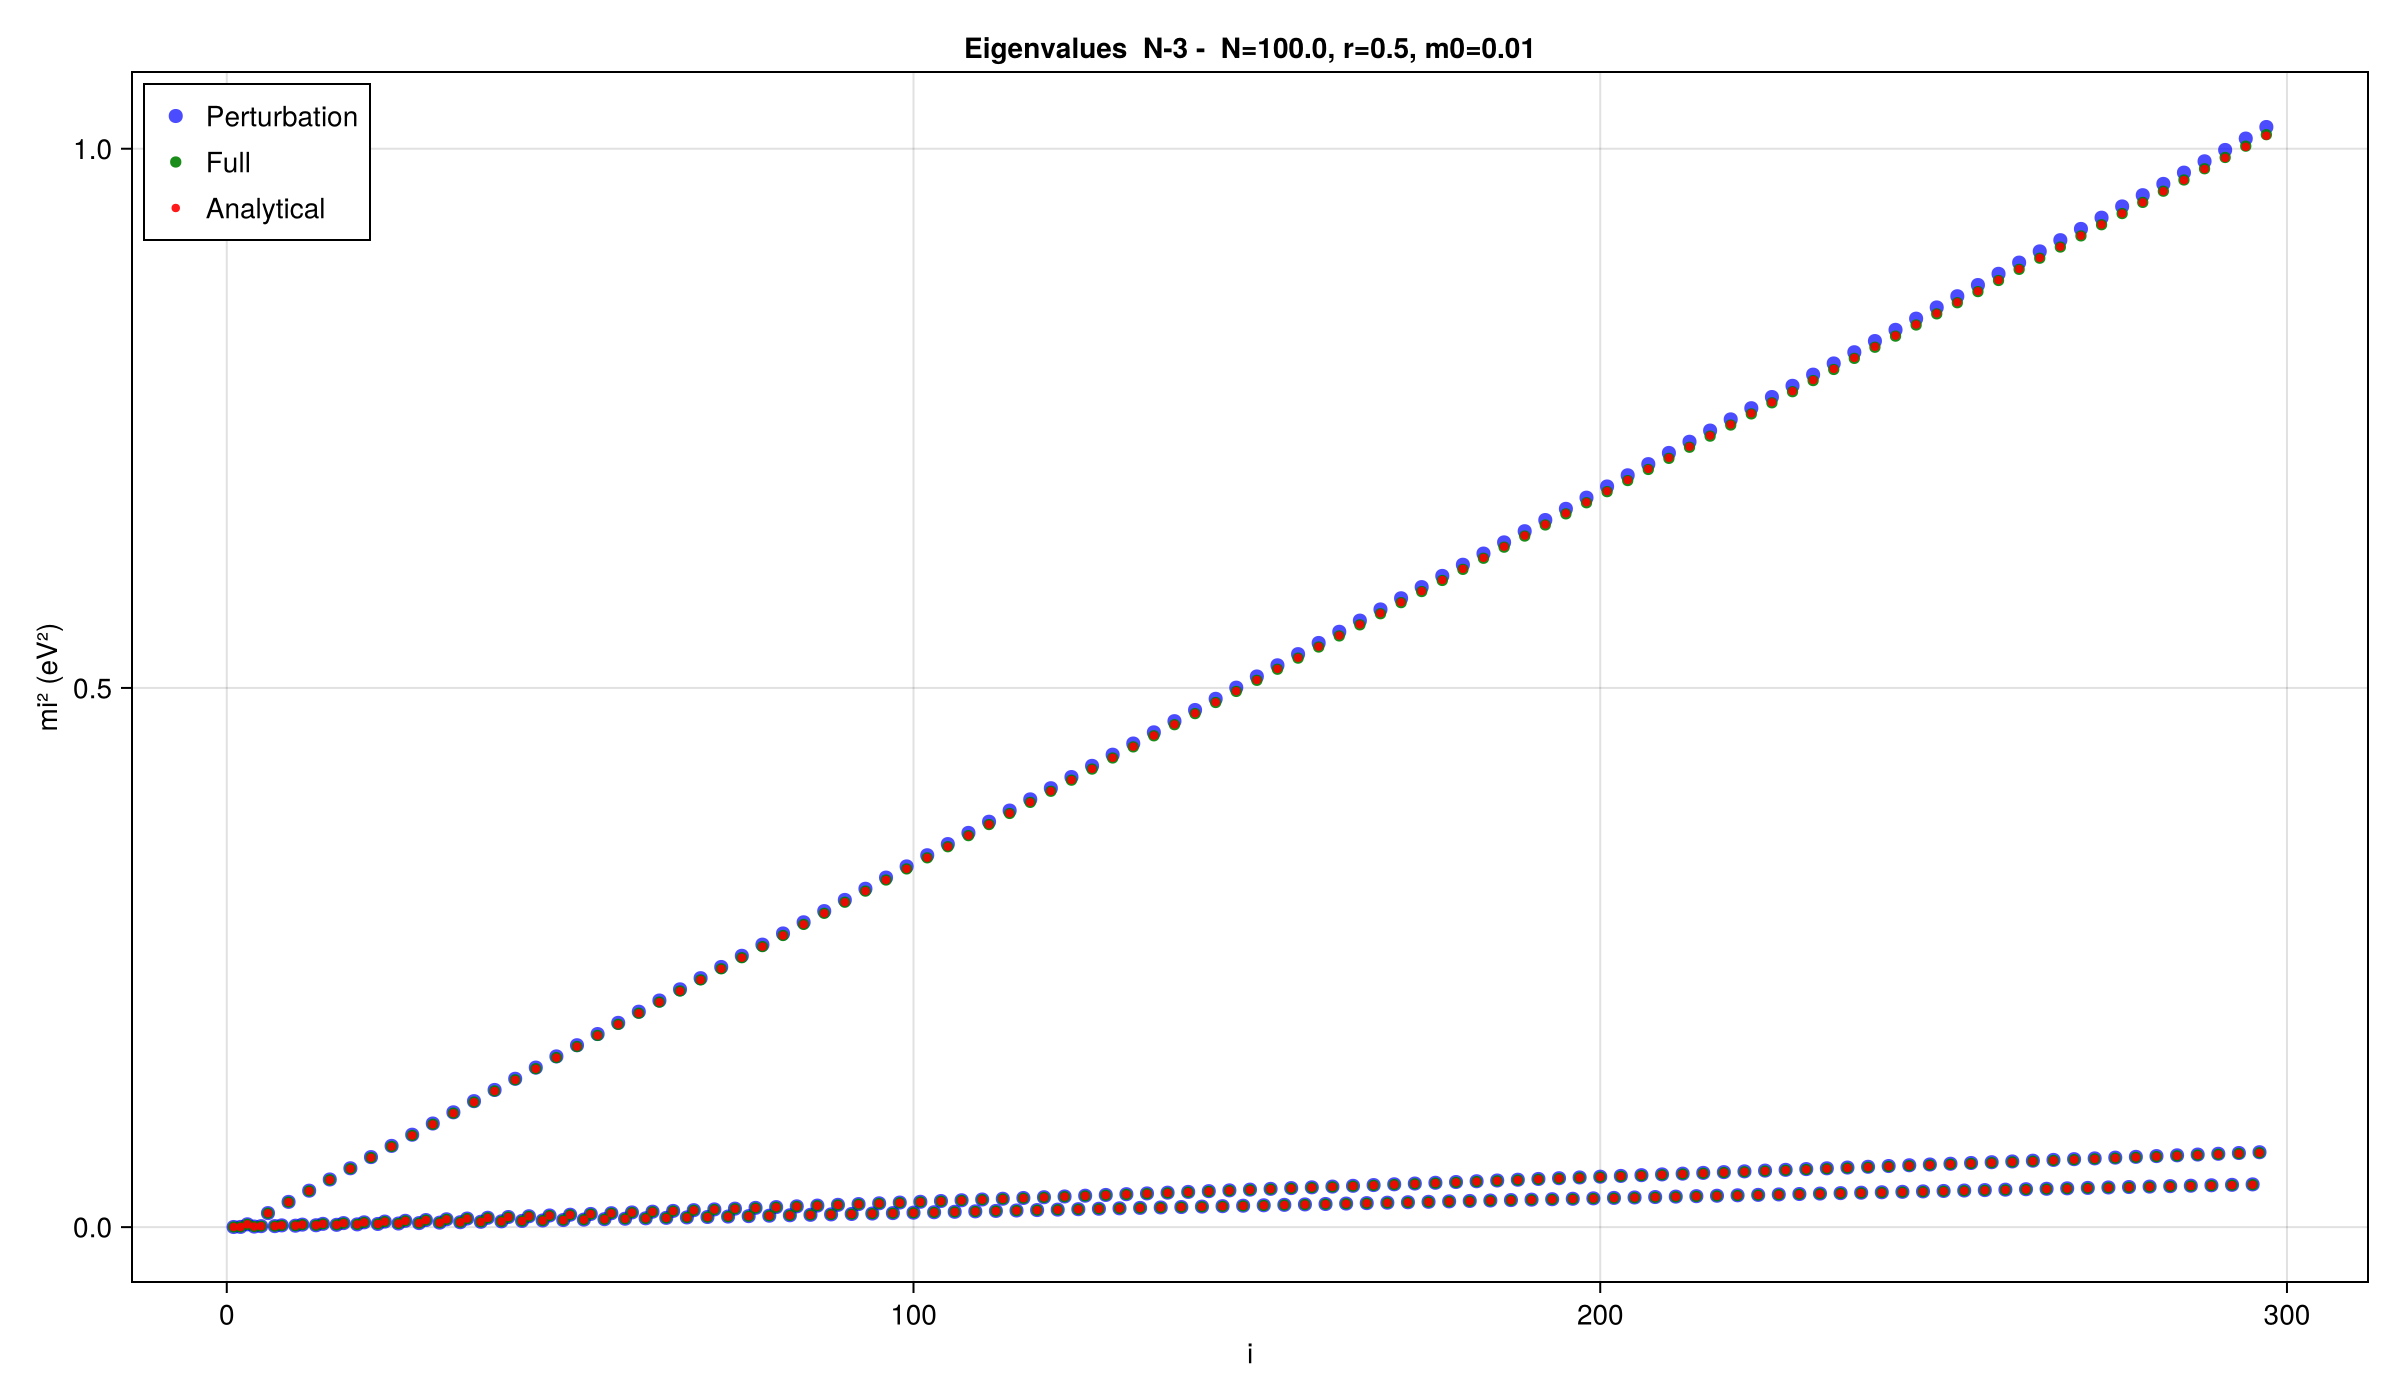

CairoMakie.Screen{IMAGE}


In [131]:
using CairoMakie
using DelimitedFiles

# Read the three txt files
file1 = vec(readdlm("/home/sofialon/Newtrinos.jl/plots_NP/pert_full/eigenvalues_pert_NND_ NO_$N $r $m0.txt"))
file2 = vec(readdlm("/home/sofialon/Newtrinos.jl/plots_NP/pert_full/eigenvalues_full_NND_ NO_$N $r $m0.txt"))


file1=(file1[1:end-3])
file2=(file2[1:end-3])

# Create indices for x-axis
indices1 = 1:length(file1)
indices2 = 1:length(file2)

# Create the plot
fig = Figure(size=(1200, 700))
ax = Axis(fig[1, 1],
    xlabel="i",
    ylabel="mi² (eV²)",
    title="Eigenvalues  N-3 -  N=$N, r=$r, m0=$m0")

# Plot scatter points for each file with different colors

scatter!(ax, indices1, file1, label="Perturbation", markersize=10, alpha=0.7, color=:blue)

scatter!(ax, indices2, file2, label="Full", markersize=8, alpha=0.9, color=:green)

scatter!(ax, indices2, eigen_analytical[1:end-3], label="Analytical", markersize=6, alpha=0.9, color=:red)
#ylims!(ax, -1e-4, 1e-4)
# Add legend
axislegend(ax, position=:lt)

# Save and display
#save("/home/sofialon/Newtrinos.jl/plots_NP/pert_full/eigenvalues_comp_NND_NO_$N $r $m0.png", fig)
display(fig)


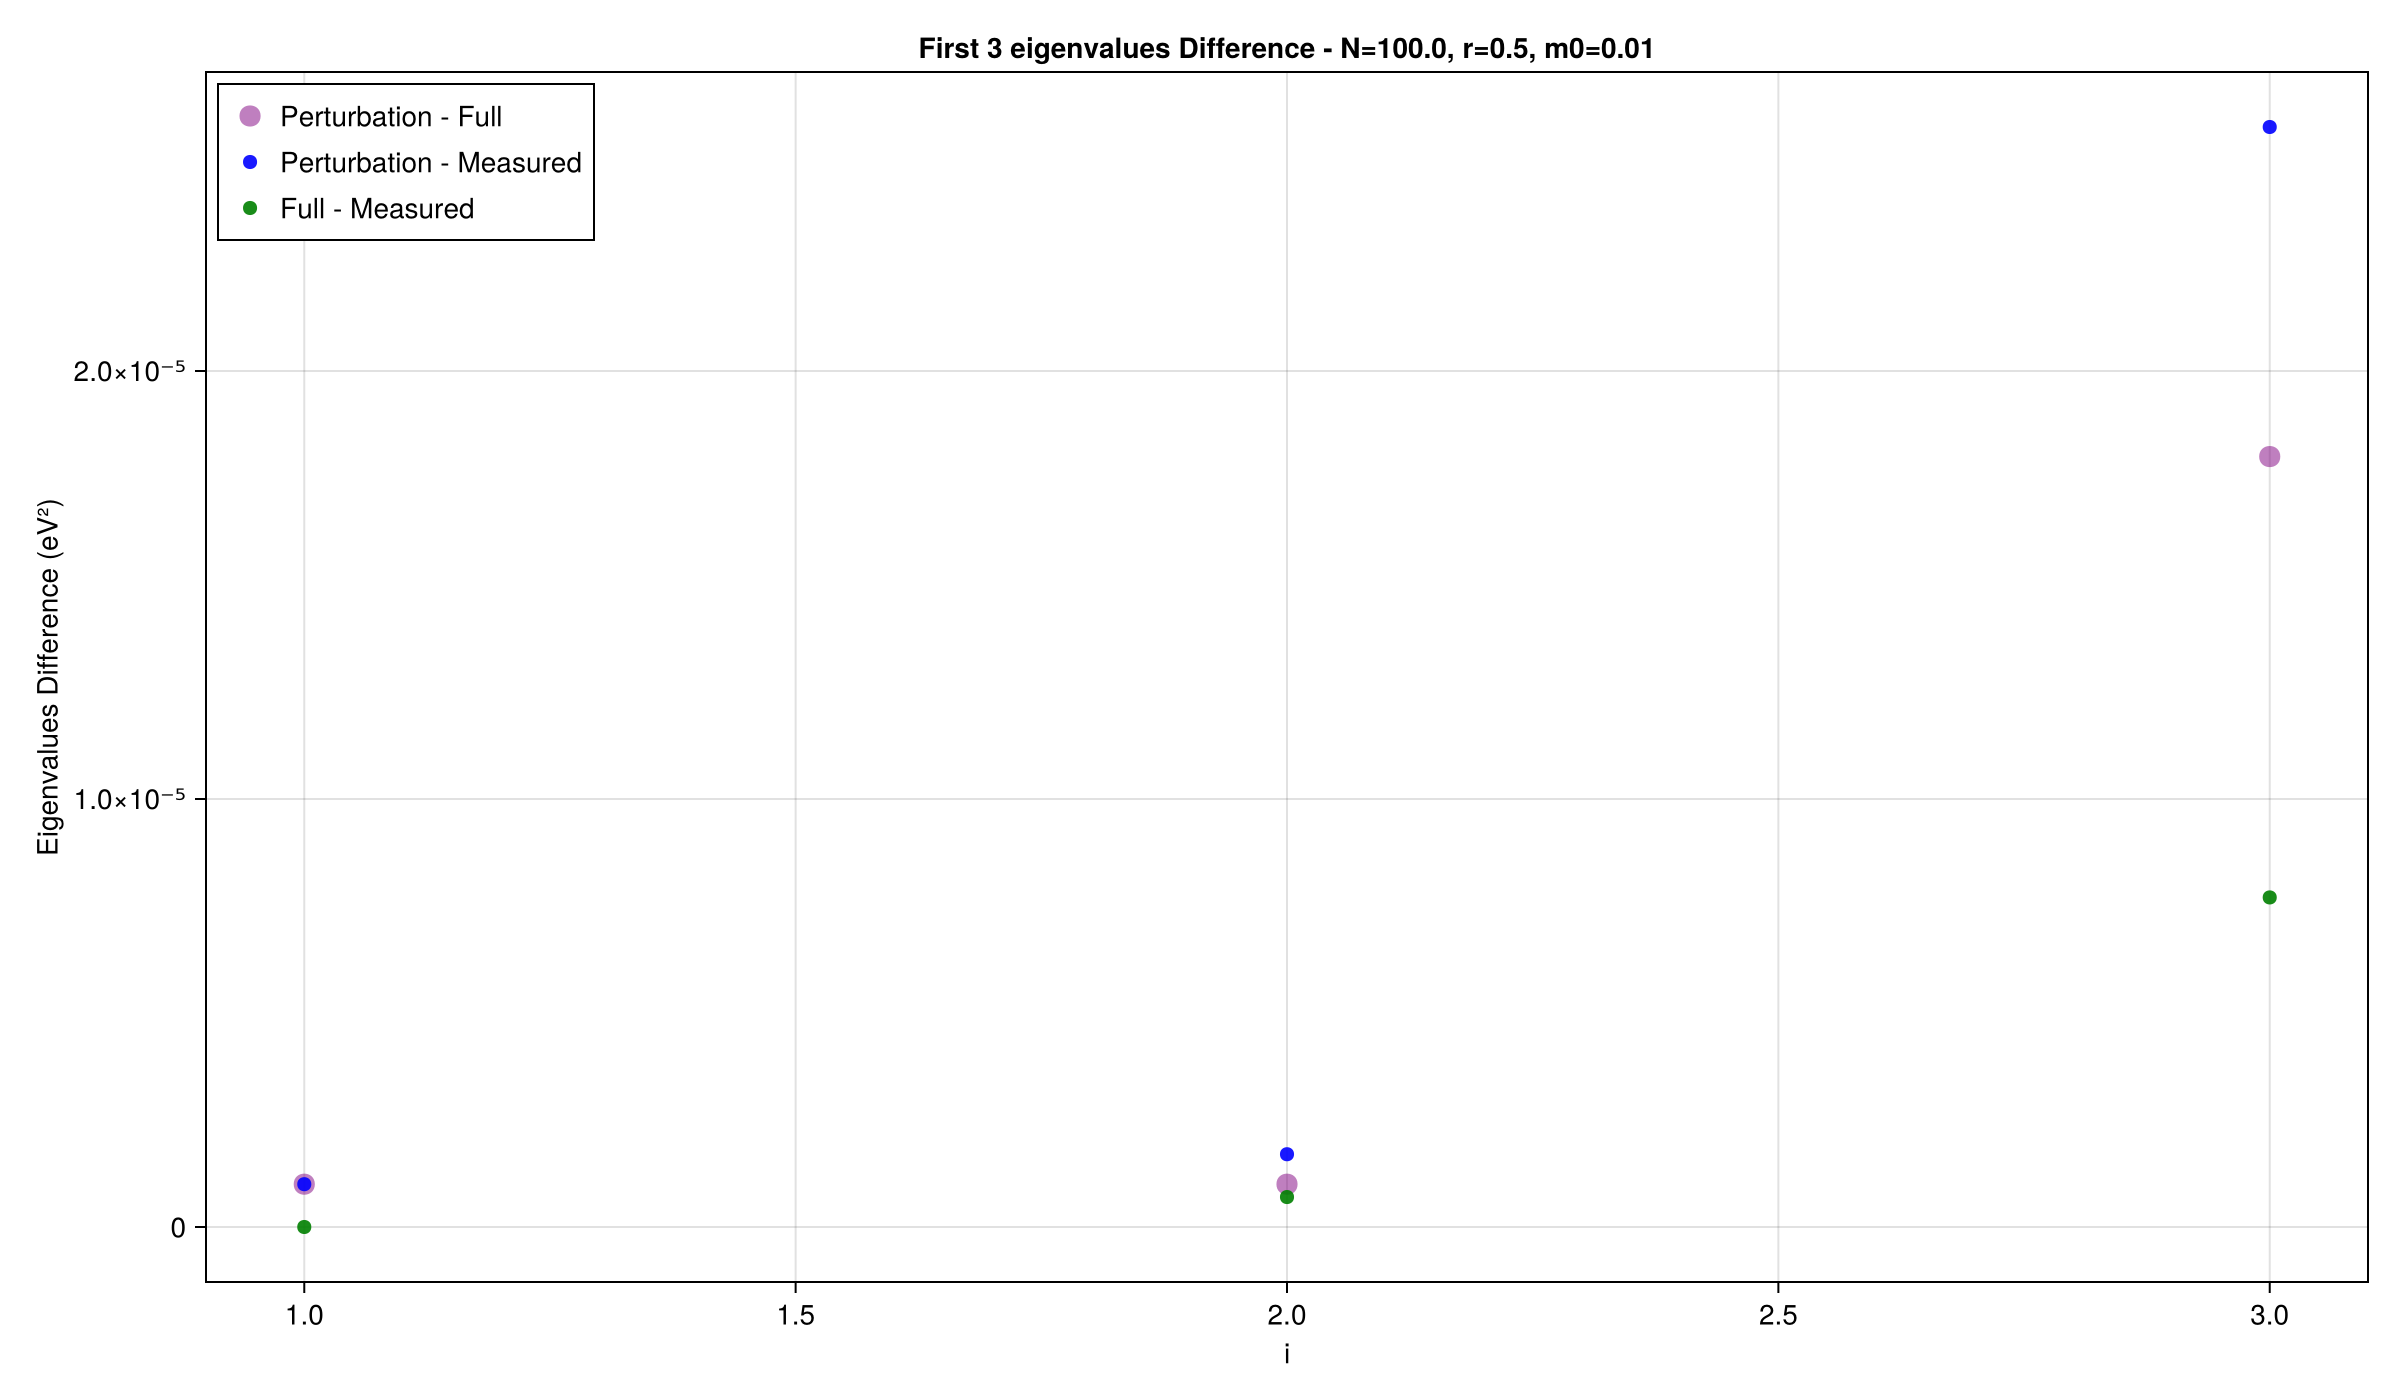

CairoMakie.Screen{IMAGE}


In [132]:


residues_1 = vec(((file1 .- file2) ))#./ file1) .* 100)
residues_2 = vec(((file1 .- eigen_analytical[1:end-3]) ))#./ file1) .* 100)
residues_3 = vec(((file2 .- eigen_analytical[1:end-3])) )#./ file2) .* 100)

# Create the plot
fig = Figure(size=(1200, 700))
ax = Axis(fig[1, 1],
    xlabel="i",
    ylabel="Eigenvalues Difference (eV²)",
    title="First 3 eigenvalues Difference - N=$N, r=$r, m0=$m0")

# Plot scatter points for each file with different colors

scatter!(ax, indices1[1:3], residues_1[1:3], label="Perturbation - Full", markersize=15, alpha=0.5, color=:purple)
scatter!(ax,  indices1[1:3], residues_2[1:3], label="Perturbation - Measured", markersize=10, alpha=0.9, color=:blue)
scatter!(ax, indices2[1:3], residues_3[1:3], label="Full - Measured", markersize=10, alpha=0.9, color=:green)



#ylims!(ax, -1e-4, 1e-4)
# Add legend
axislegend(ax, position=:lt)

# Save and display
save("/home/sofialon/Newtrinos.jl/plots_NP/pert_full/eigenvalues_diff3_NND_NO_$N $r $m0.png", fig)
display(fig)


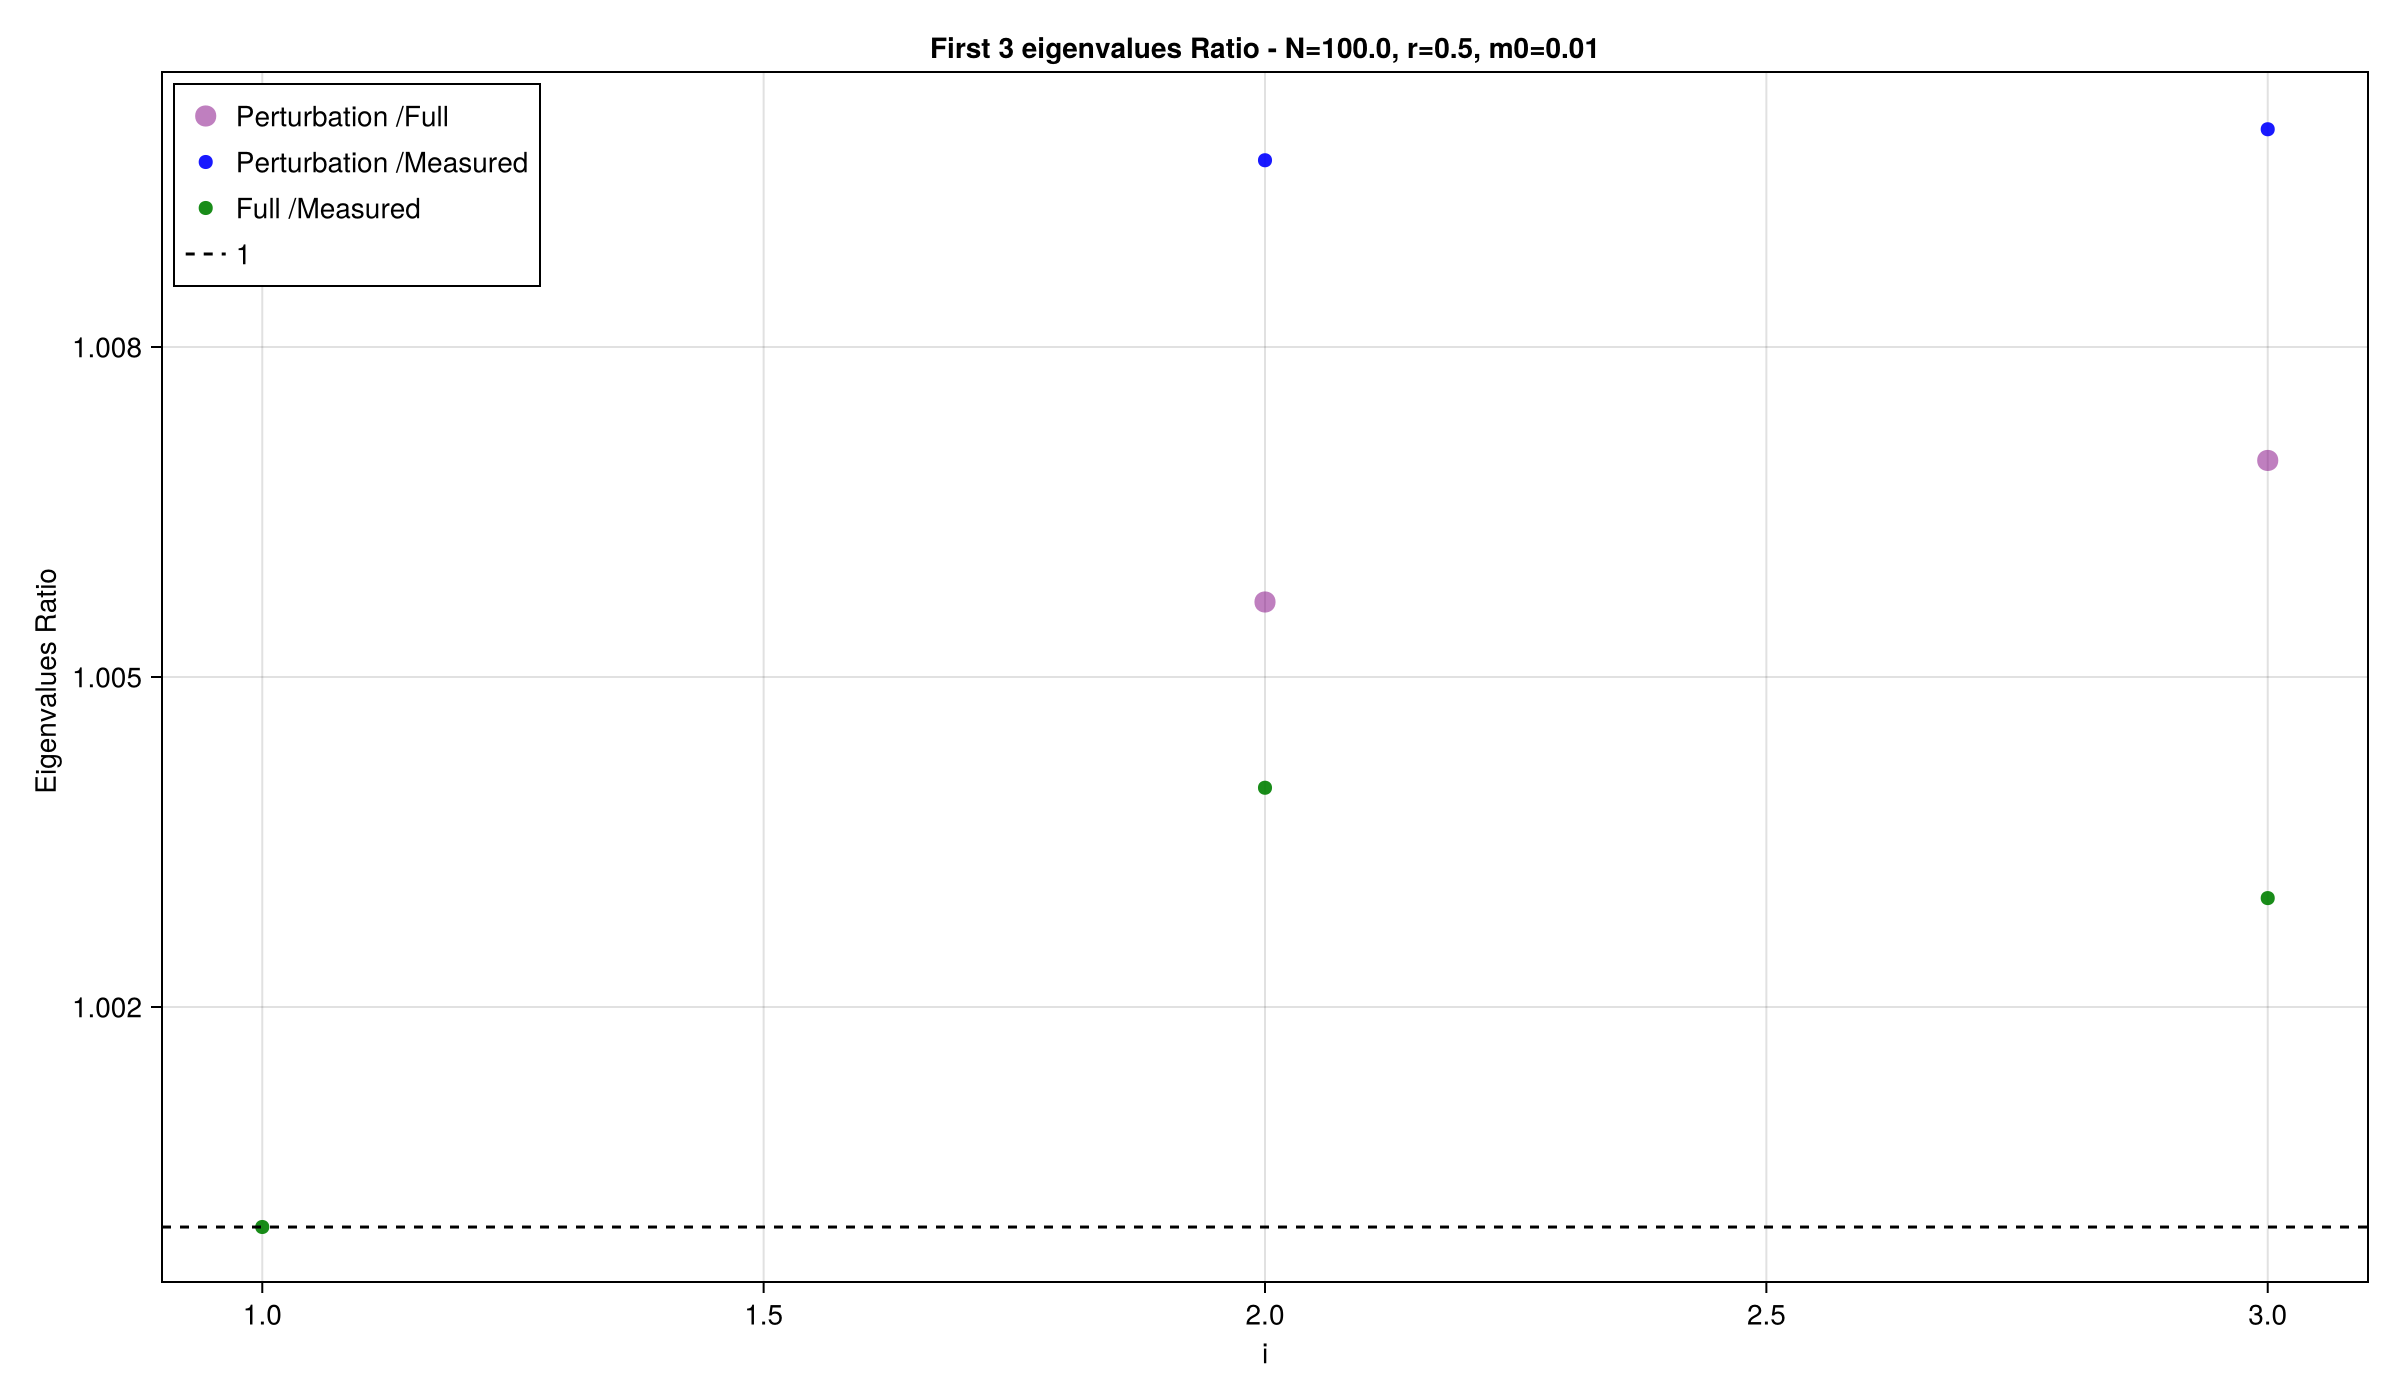

CairoMakie.Screen{IMAGE}


In [133]:


residues_1 = vec(((file1 ./ file2) ))#./ file1) .* 100)
residues_2 = vec(((file1 ./ eigen_analytical[1:end-3]) ))#./ file1) .* 100)
residues_3 = vec(((file2 ./ eigen_analytical[1:end-3])) )#./ file2) .* 100)

# Create the plot
fig = Figure(size=(1200, 700))
ax = Axis(fig[1, 1],
    xlabel="i",
    ylabel="Eigenvalues Ratio ",
    title="First 3 eigenvalues Ratio - N=$N, r=$r, m0=$m0")

# Plot scatter points for each file with different colors

scatter!(ax, indices1[1:3], residues_1[1:3], label="Perturbation /Full", markersize=15, alpha=0.5, color=:purple)
scatter!(ax,  indices1[1:3], residues_2[1:3], label="Perturbation /Measured", markersize=10, alpha=0.9, color=:blue)
scatter!(ax, indices2[1:3], residues_3[1:3], label="Full /Measured", markersize=10, alpha=0.9, color=:green)
hlines!(ax, 1, color=:black, linestyle=:dash, label="1")

#ylims!(ax, -1e-4, 1e-4)
# Add legend
axislegend(ax, position=:lt)

# Save and display
save("/home/sofialon/Newtrinos.jl/plots_NP/pert_full/eigenvalues_ratio3_NND_NO_$N $r $m0.png", fig)
display(fig)


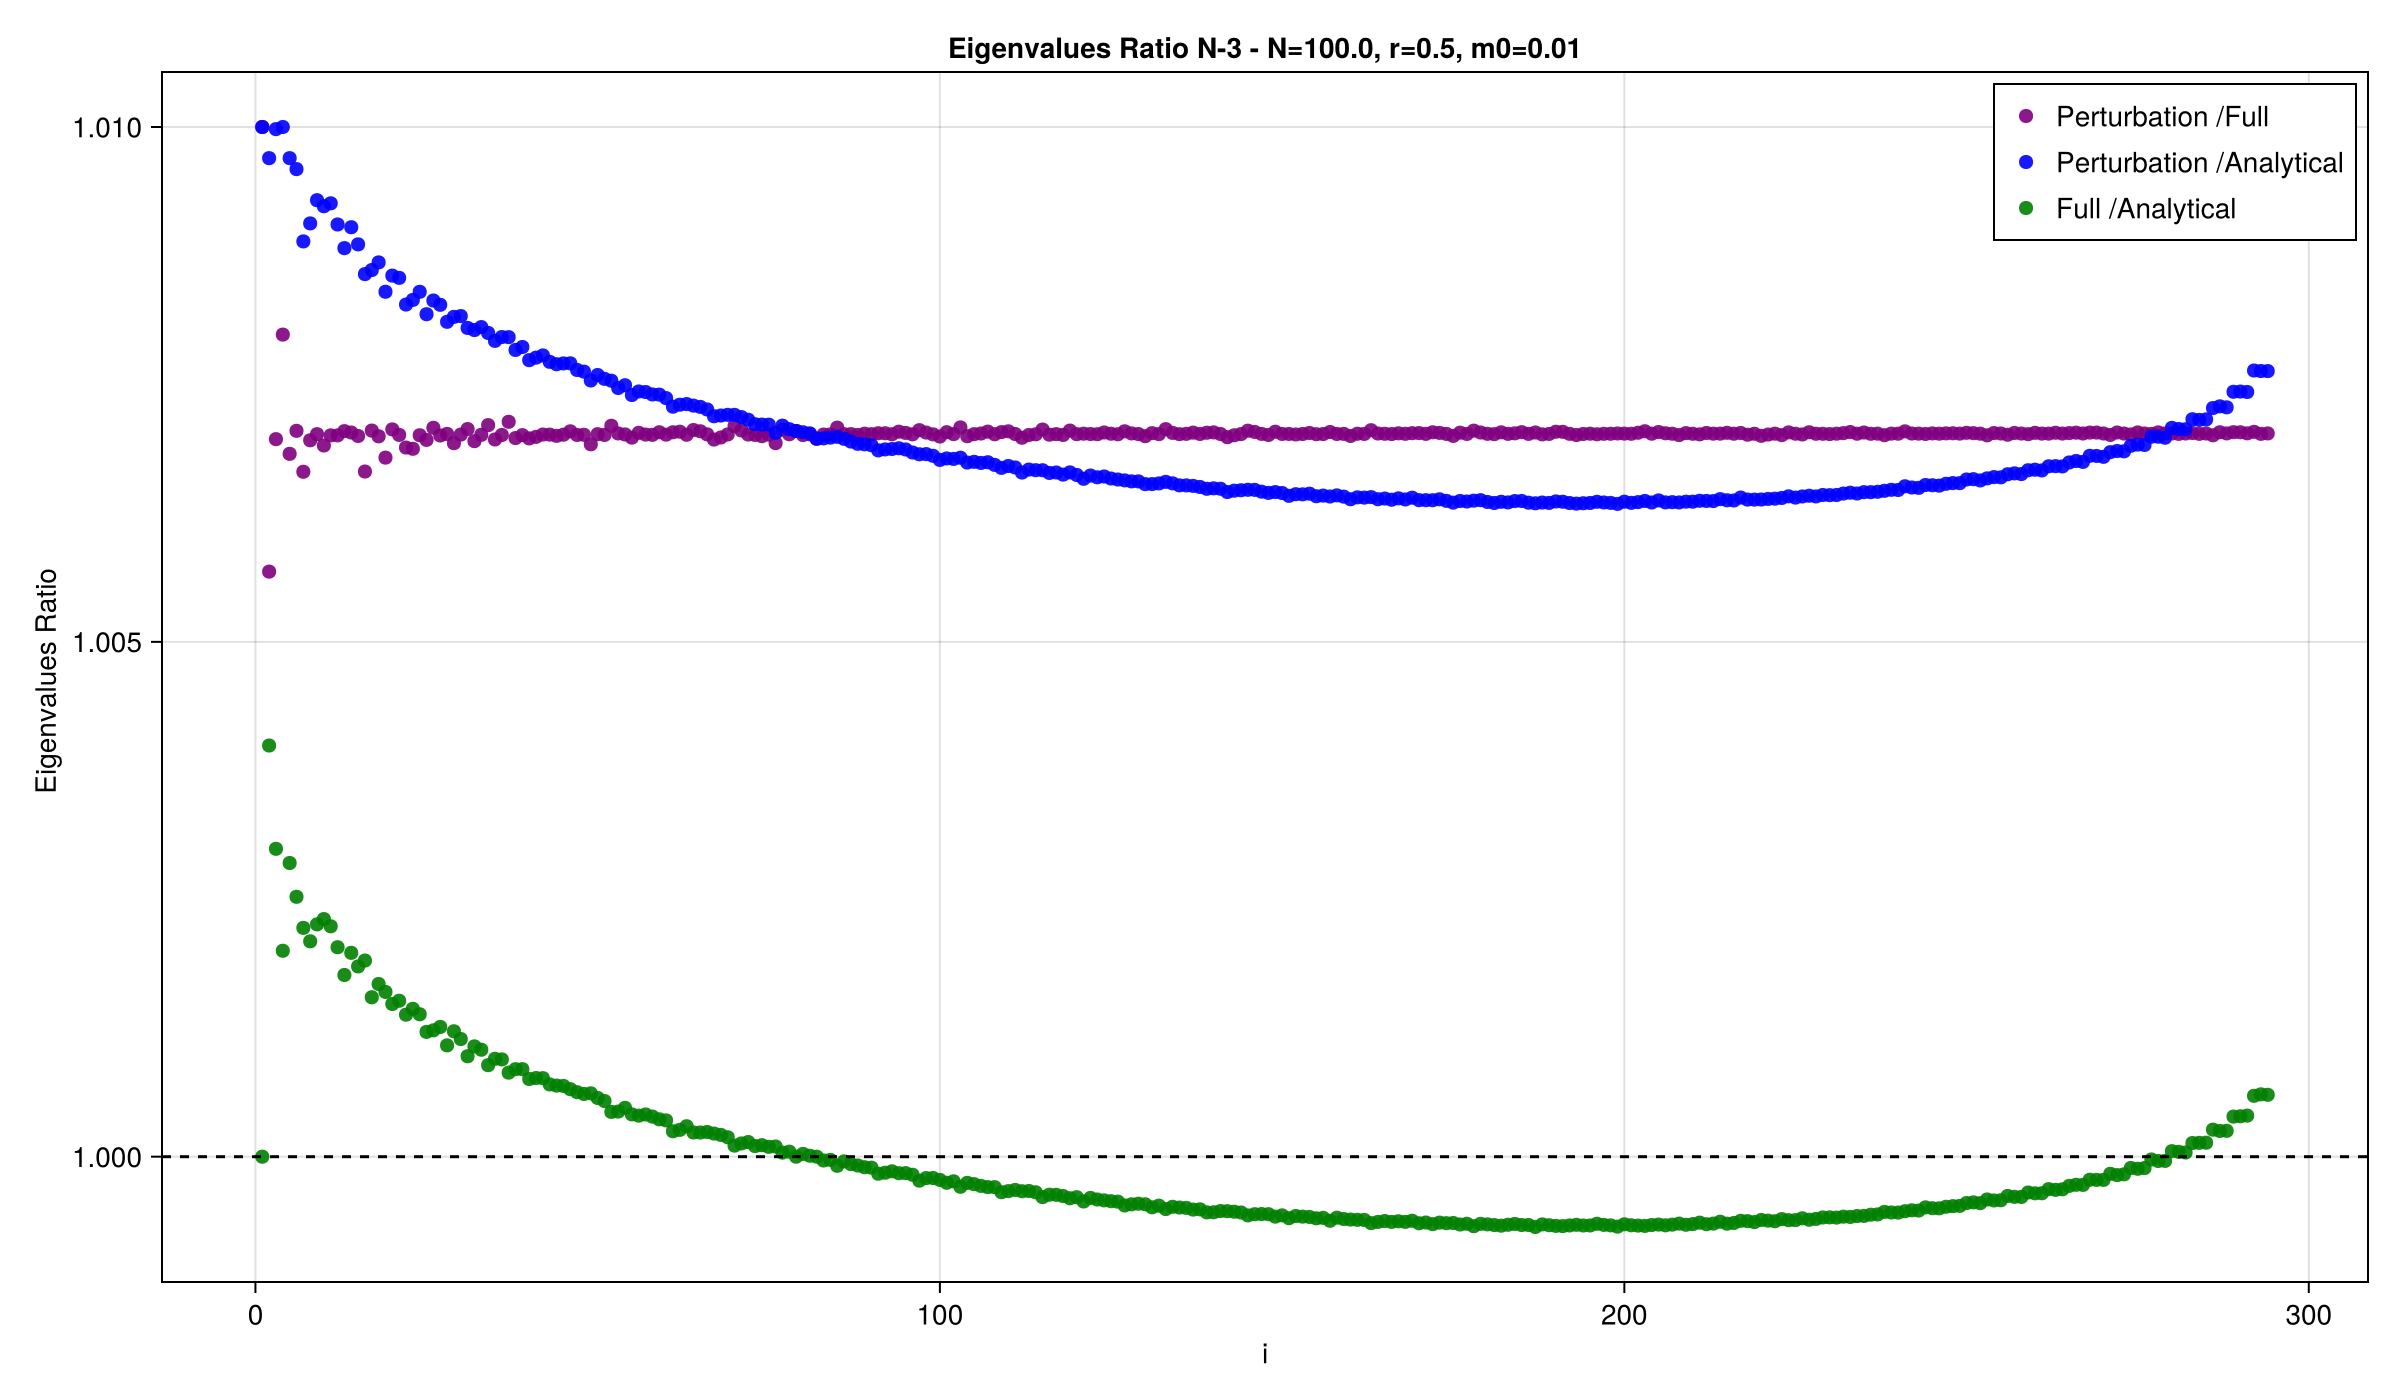

CairoMakie.Screen{IMAGE}


In [134]:



residues_1 = vec(((file1 ./ file2) ))#./ file1) .* 100)
residues_2 = vec(((file1 ./ eigen_analytical[1:end-3]) ))#./ file1) .* 100)
residues_3 = vec(((file2 ./ eigen_analytical[1:end-3])) )#./ file2) .* 100)



# Create the plot
fig = Figure(size=(1200, 700))
ax = Axis(fig[1, 1],
    xlabel="i",
    ylabel="Eigenvalues Ratio ",
    title="Eigenvalues Ratio N-3 - N=$N, r=$r, m0=$m0")

# Plot scatter points for each file with different colors

scatter!(ax, indices1[1:end-3], residues_1[1:end-3], label="Perturbation /Full", markersize=10, alpha=0.9, color=:purple)
scatter!(ax,  indices1[1:end-3], residues_2[1:end-3], label="Perturbation /Analytical", markersize=10, alpha=0.9, color=:blue)
scatter!(ax, indices2[1:end-3], residues_3[1:end-3], label="Full /Analytical", markersize=10, alpha=0.9, color=:green)
hlines!(ax, 1, color=:black, linestyle=:dash)

#ylims!(ax, -1e-4, 1e-4)
# Add legend
axislegend(ax, position=:rt)

# Save and display
save("/home/sofialon/Newtrinos.jl/plots_NP/pert_full/eigenvalues_ratio_NND_NO_$N $r $m0.png", fig)
display(fig)


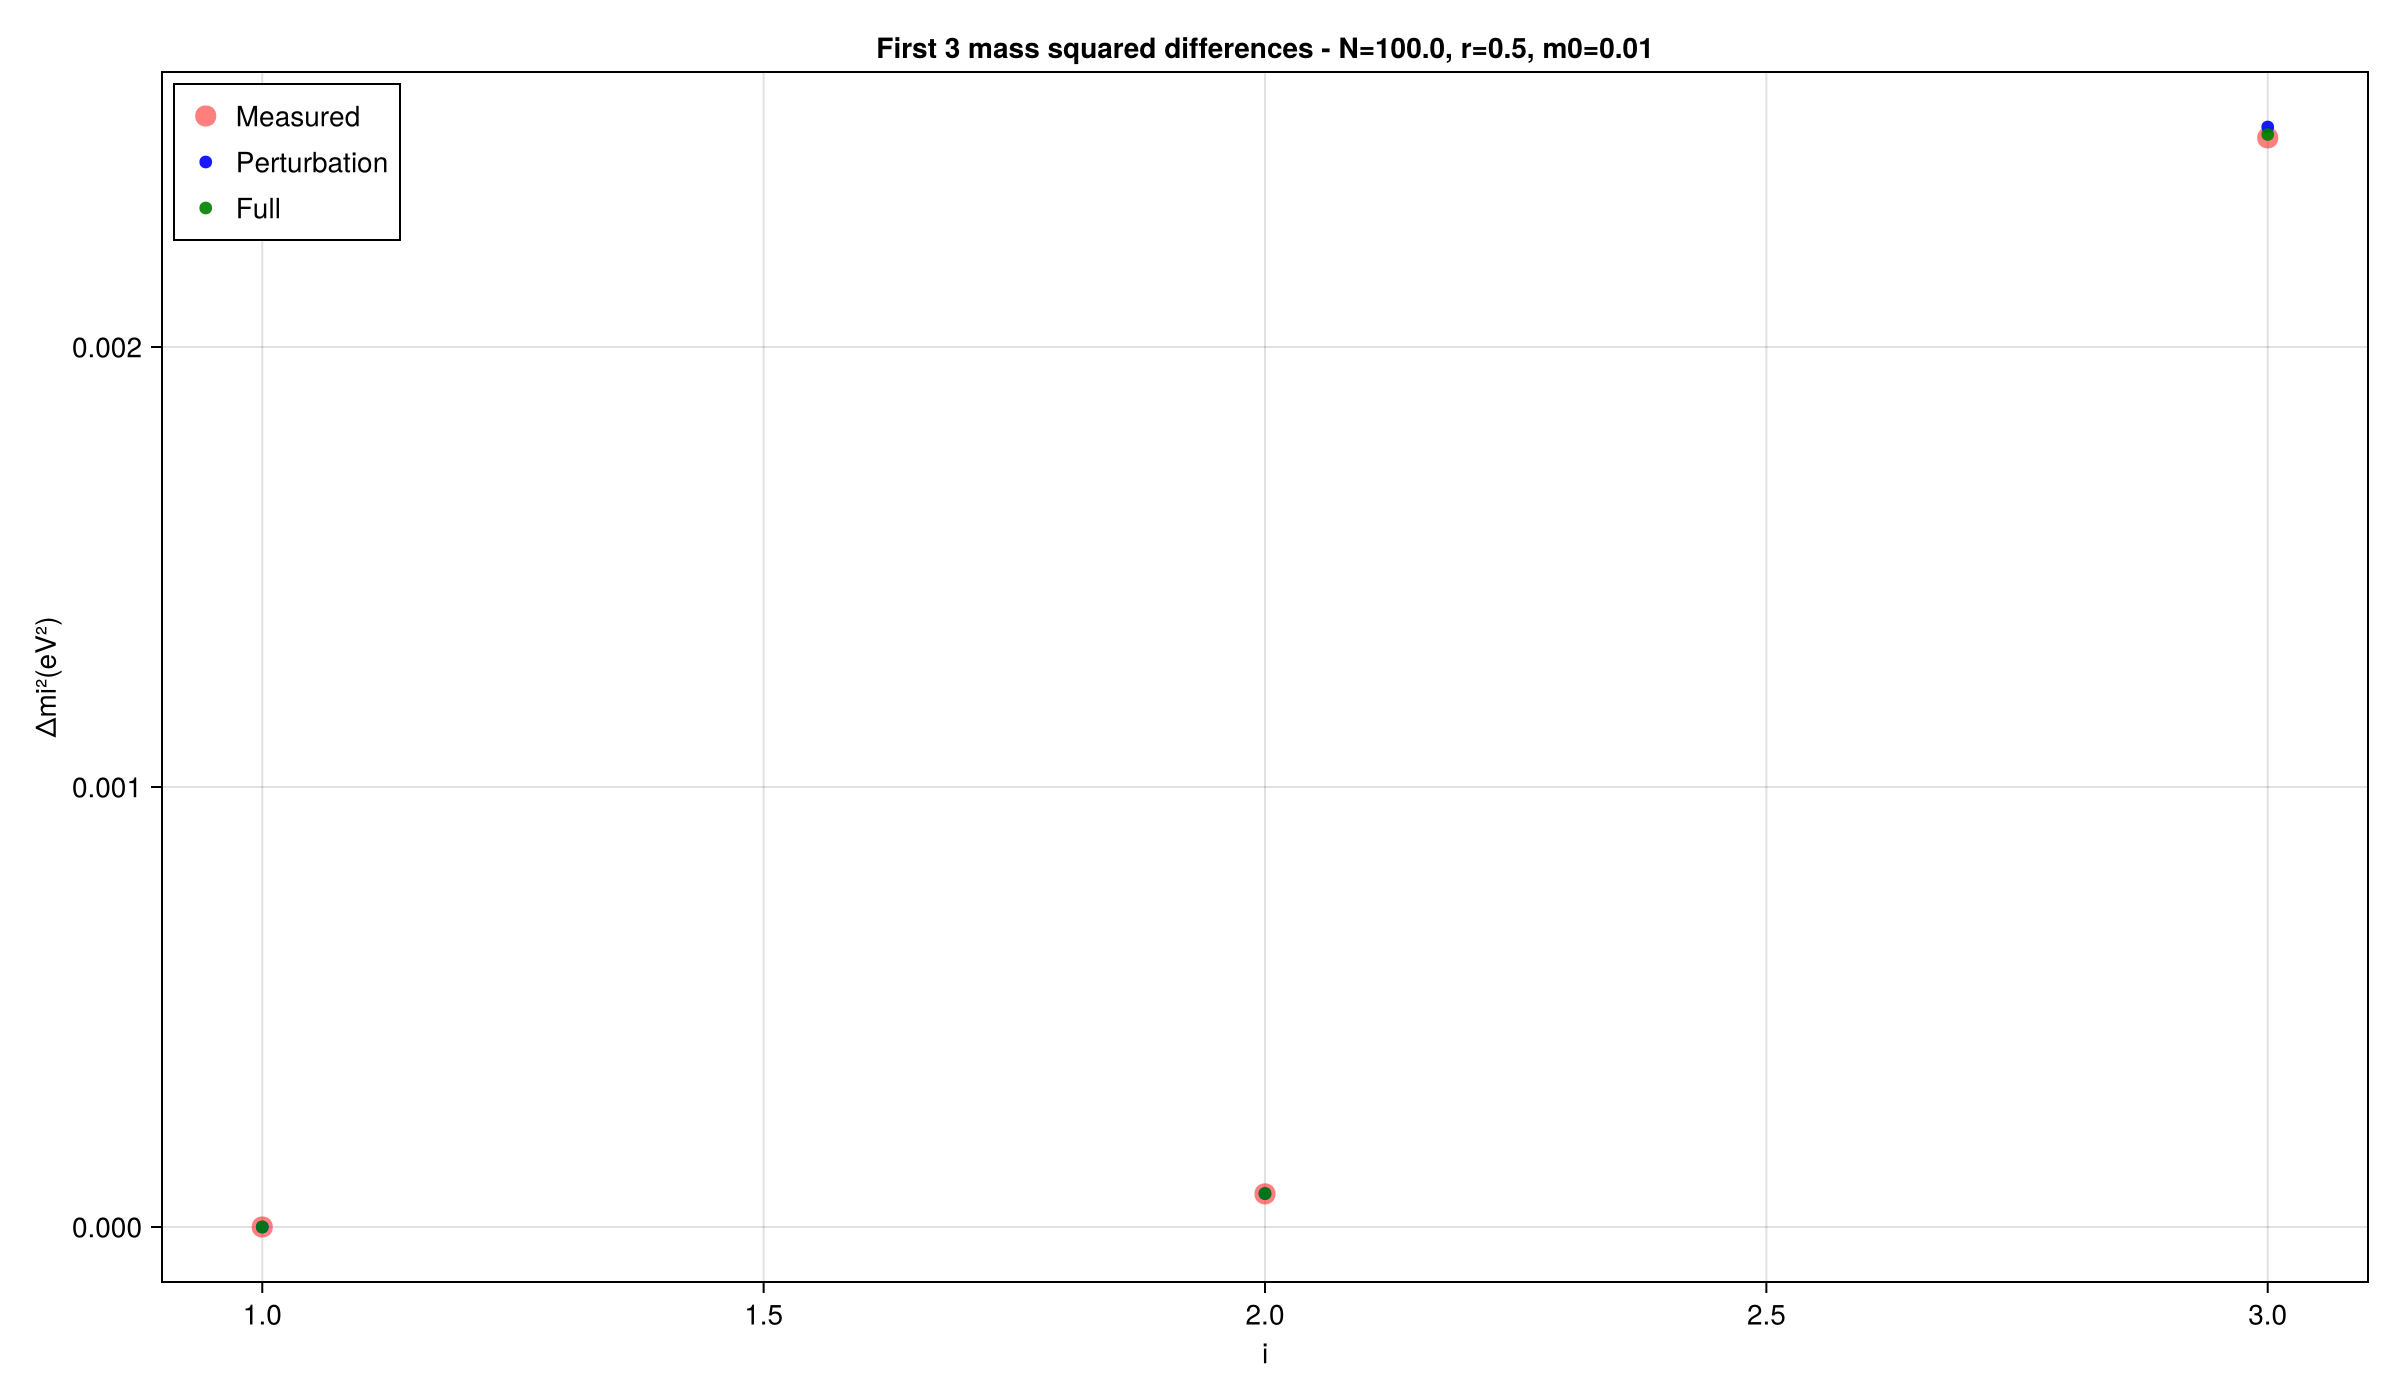

CairoMakie.Screen{IMAGE}


In [135]:

# Read the three txt files
file1_h = vec(readdlm("/home/sofialon/Newtrinos.jl/plots_NP/pert_full/h_pert_NND_ NO_$N $r $m0.txt"))
file2_h = vec(readdlm("/home/sofialon/Newtrinos.jl/plots_NP/pert_full/h_full_NND_ NO_$N $r $m0.txt"))


file1_h=(file1_h[1:end-3])
file2_h=(file2_h[1:end-3])

# Create indices for x-axis
indices1 = 1:length(file1_h)
indices2 = 1:length(file2_h)

# Create the plot
fig = Figure(size=(1200, 700))
ax = Axis(fig[1, 1],
    xlabel="i",
    ylabel="Δmi²(eV²)",
    title="First 3 mass squared differences - N=$N, r=$r, m0=$m0")

# Plot scatter points for each file with different colors
scatter!(ax, indices2[1:3], h_analytical[1:3], label="Measured", markersize=15, alpha=0.5, color=:red)
scatter!(ax, indices1[1:3], file1_h[1:3], label="Perturbation", markersize=9, alpha=0.9, color=:blue)

scatter!(ax, indices2[1:3], file2_h[1:3], label="Full", markersize=9, alpha=0.9, color=:green)


#ylims!(ax, -1e-4, 1e-4)
# Add legend
axislegend(ax, position=:lt)

# Save and display
save("/home/sofialon/Newtrinos.jl/plots_NP/pert_full/h_3_NND_NO_$N $r $m0.png", fig)
display(fig)


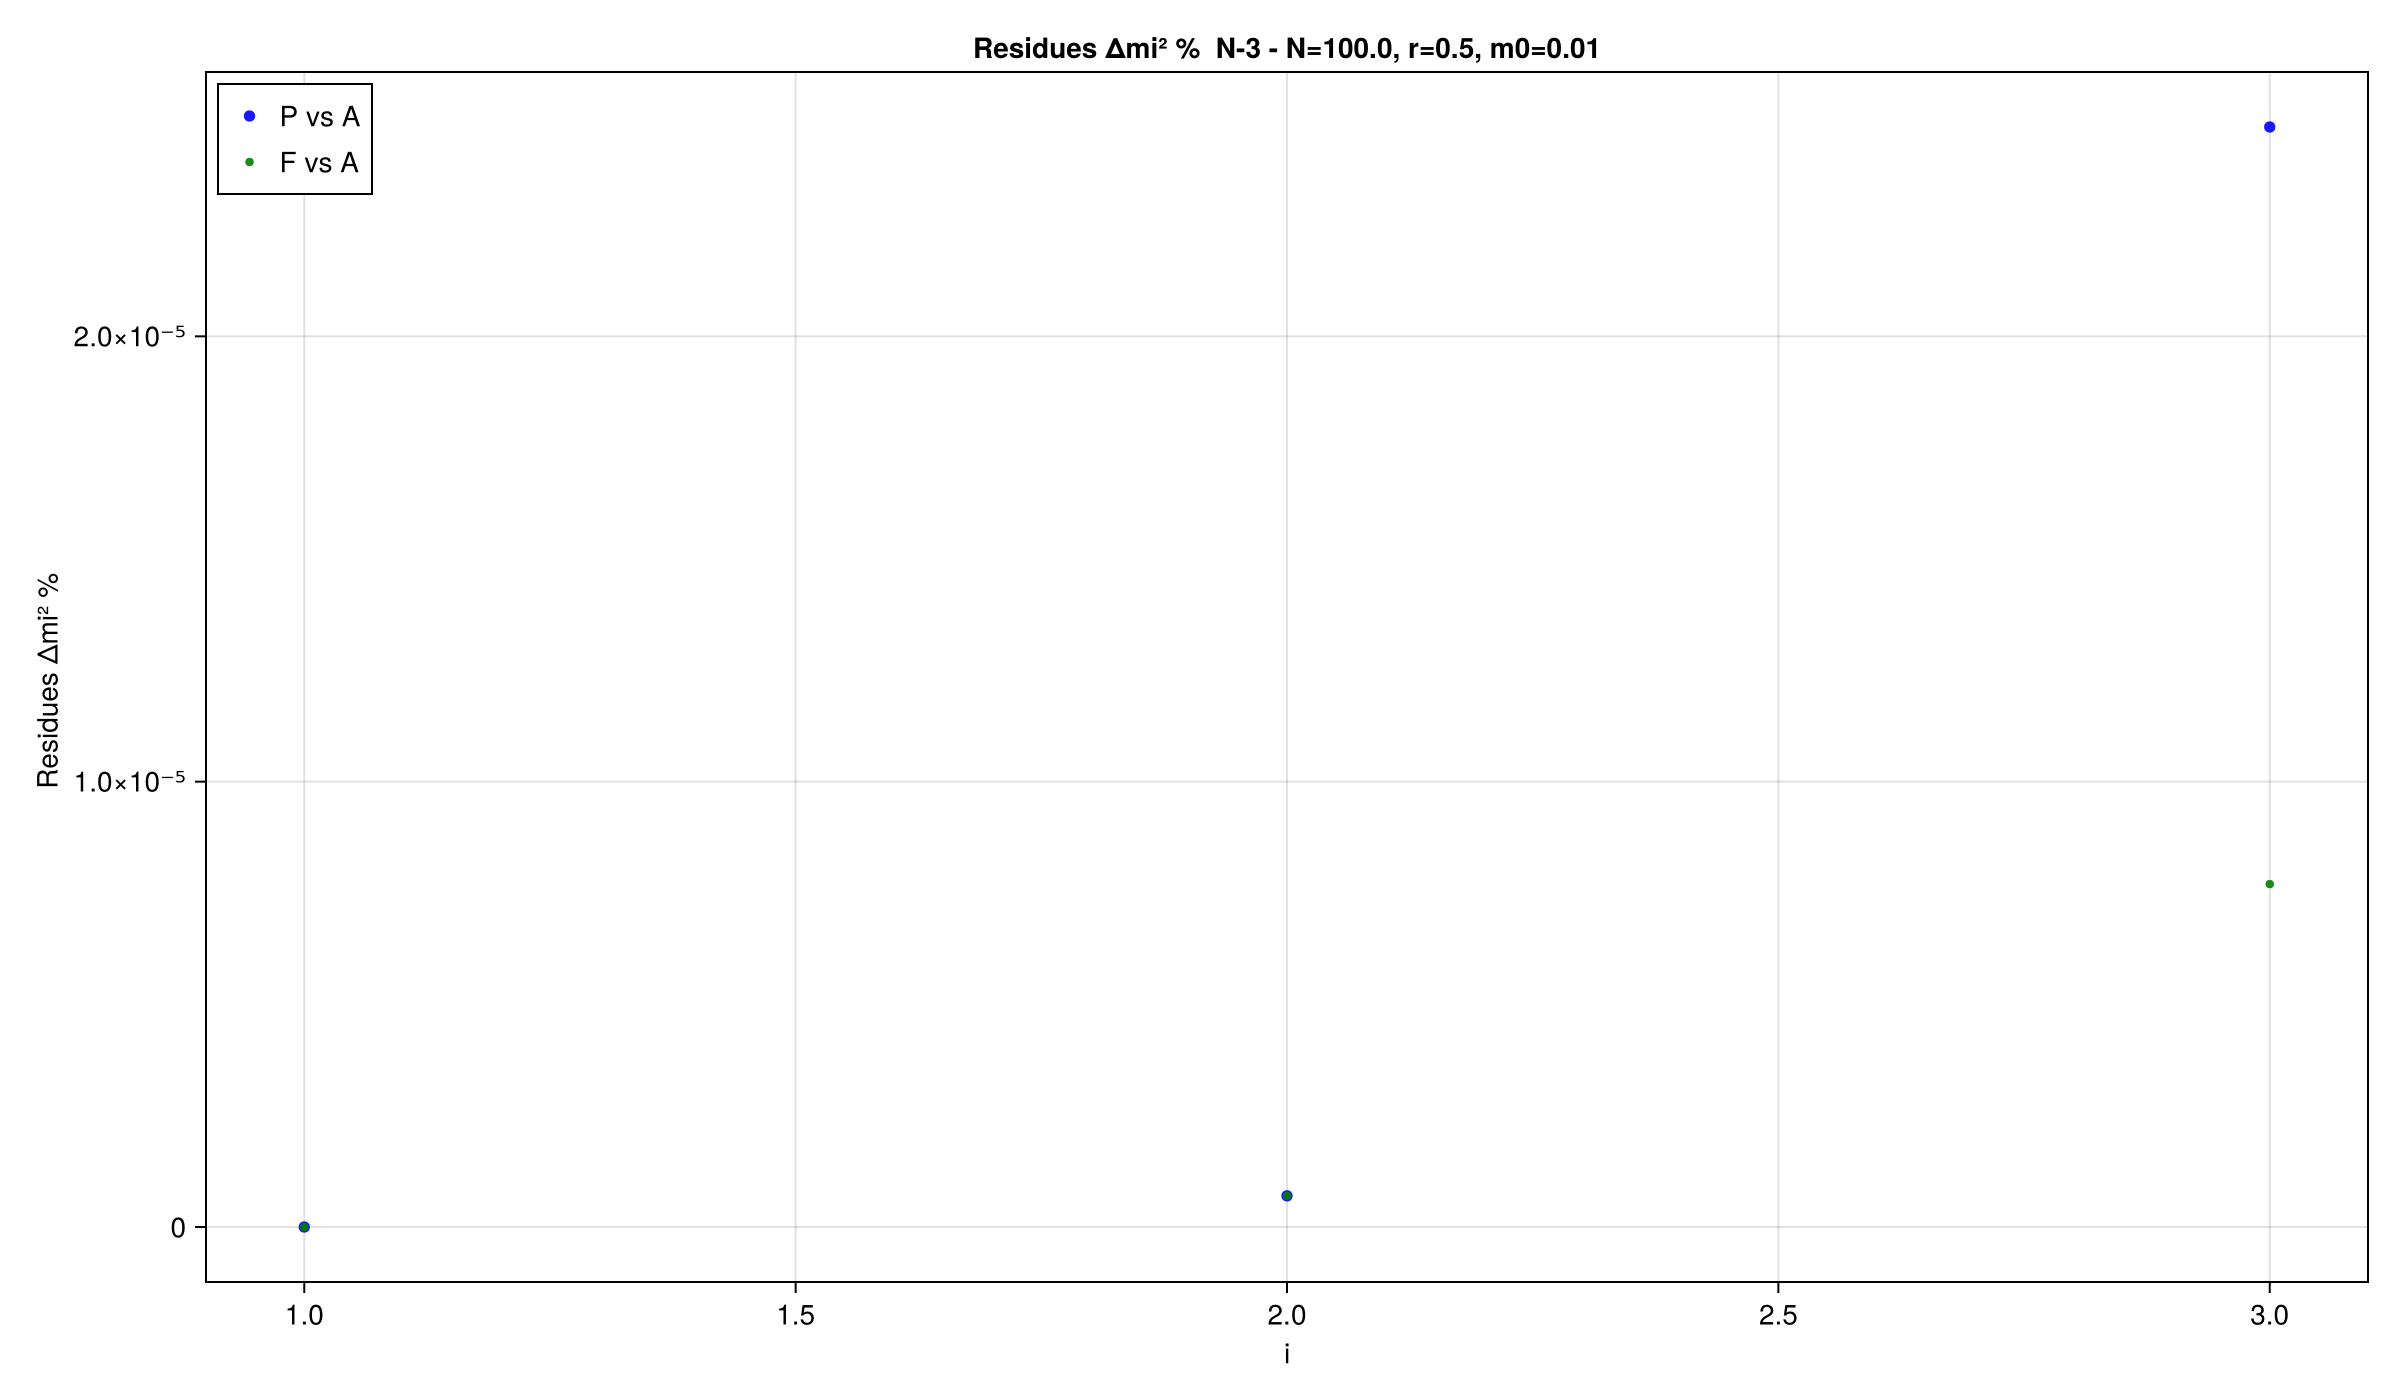

CairoMakie.Screen{IMAGE}


In [136]:

residues_1 = vec(((file1_h .- file2_h) ./ file1_h) .* 100)
residues_2 = vec(((file1_h .- (h_analytical[1:end-3])) ))#./ file1_h) .* 100)
residues_3 = vec(((file2_h .- (h_analytical[1:end-3]))) )#./ file2_h) .* 100)


# Create the plot
fig = Figure(size=(1200, 700))
ax = Axis(fig[1, 1],
    xlabel="i",
    ylabel="Residues Δmi² % ",
    title="Residues Δmi² %  N-3 - N=$N, r=$r, m0=$m0")

# Plot scatter points for each file with different colors

#scatter!(ax, indices1[1:3], residues_1[1:3], label="P vs F", markersize=10, alpha=0.7, color=:purple)
scatter!(ax, indices1[1:3], residues_2[1:3], label="P vs A", markersize=8, alpha=0.9, color=:blue)
scatter!(ax, indices2[1:3], residues_3[1:3], label="F vs A", markersize=6, alpha=0.9, color=:green)


#ylims!(ax, -1e-4, 1e-4)
# Add legend
axislegend(ax, position=:lt)

# Save and display
#save("/home/sofialon/Newtrinos.jl/plots_NP/pert_full/h_res_NND_NO_$N $r $m0.png", fig)
display(fig)


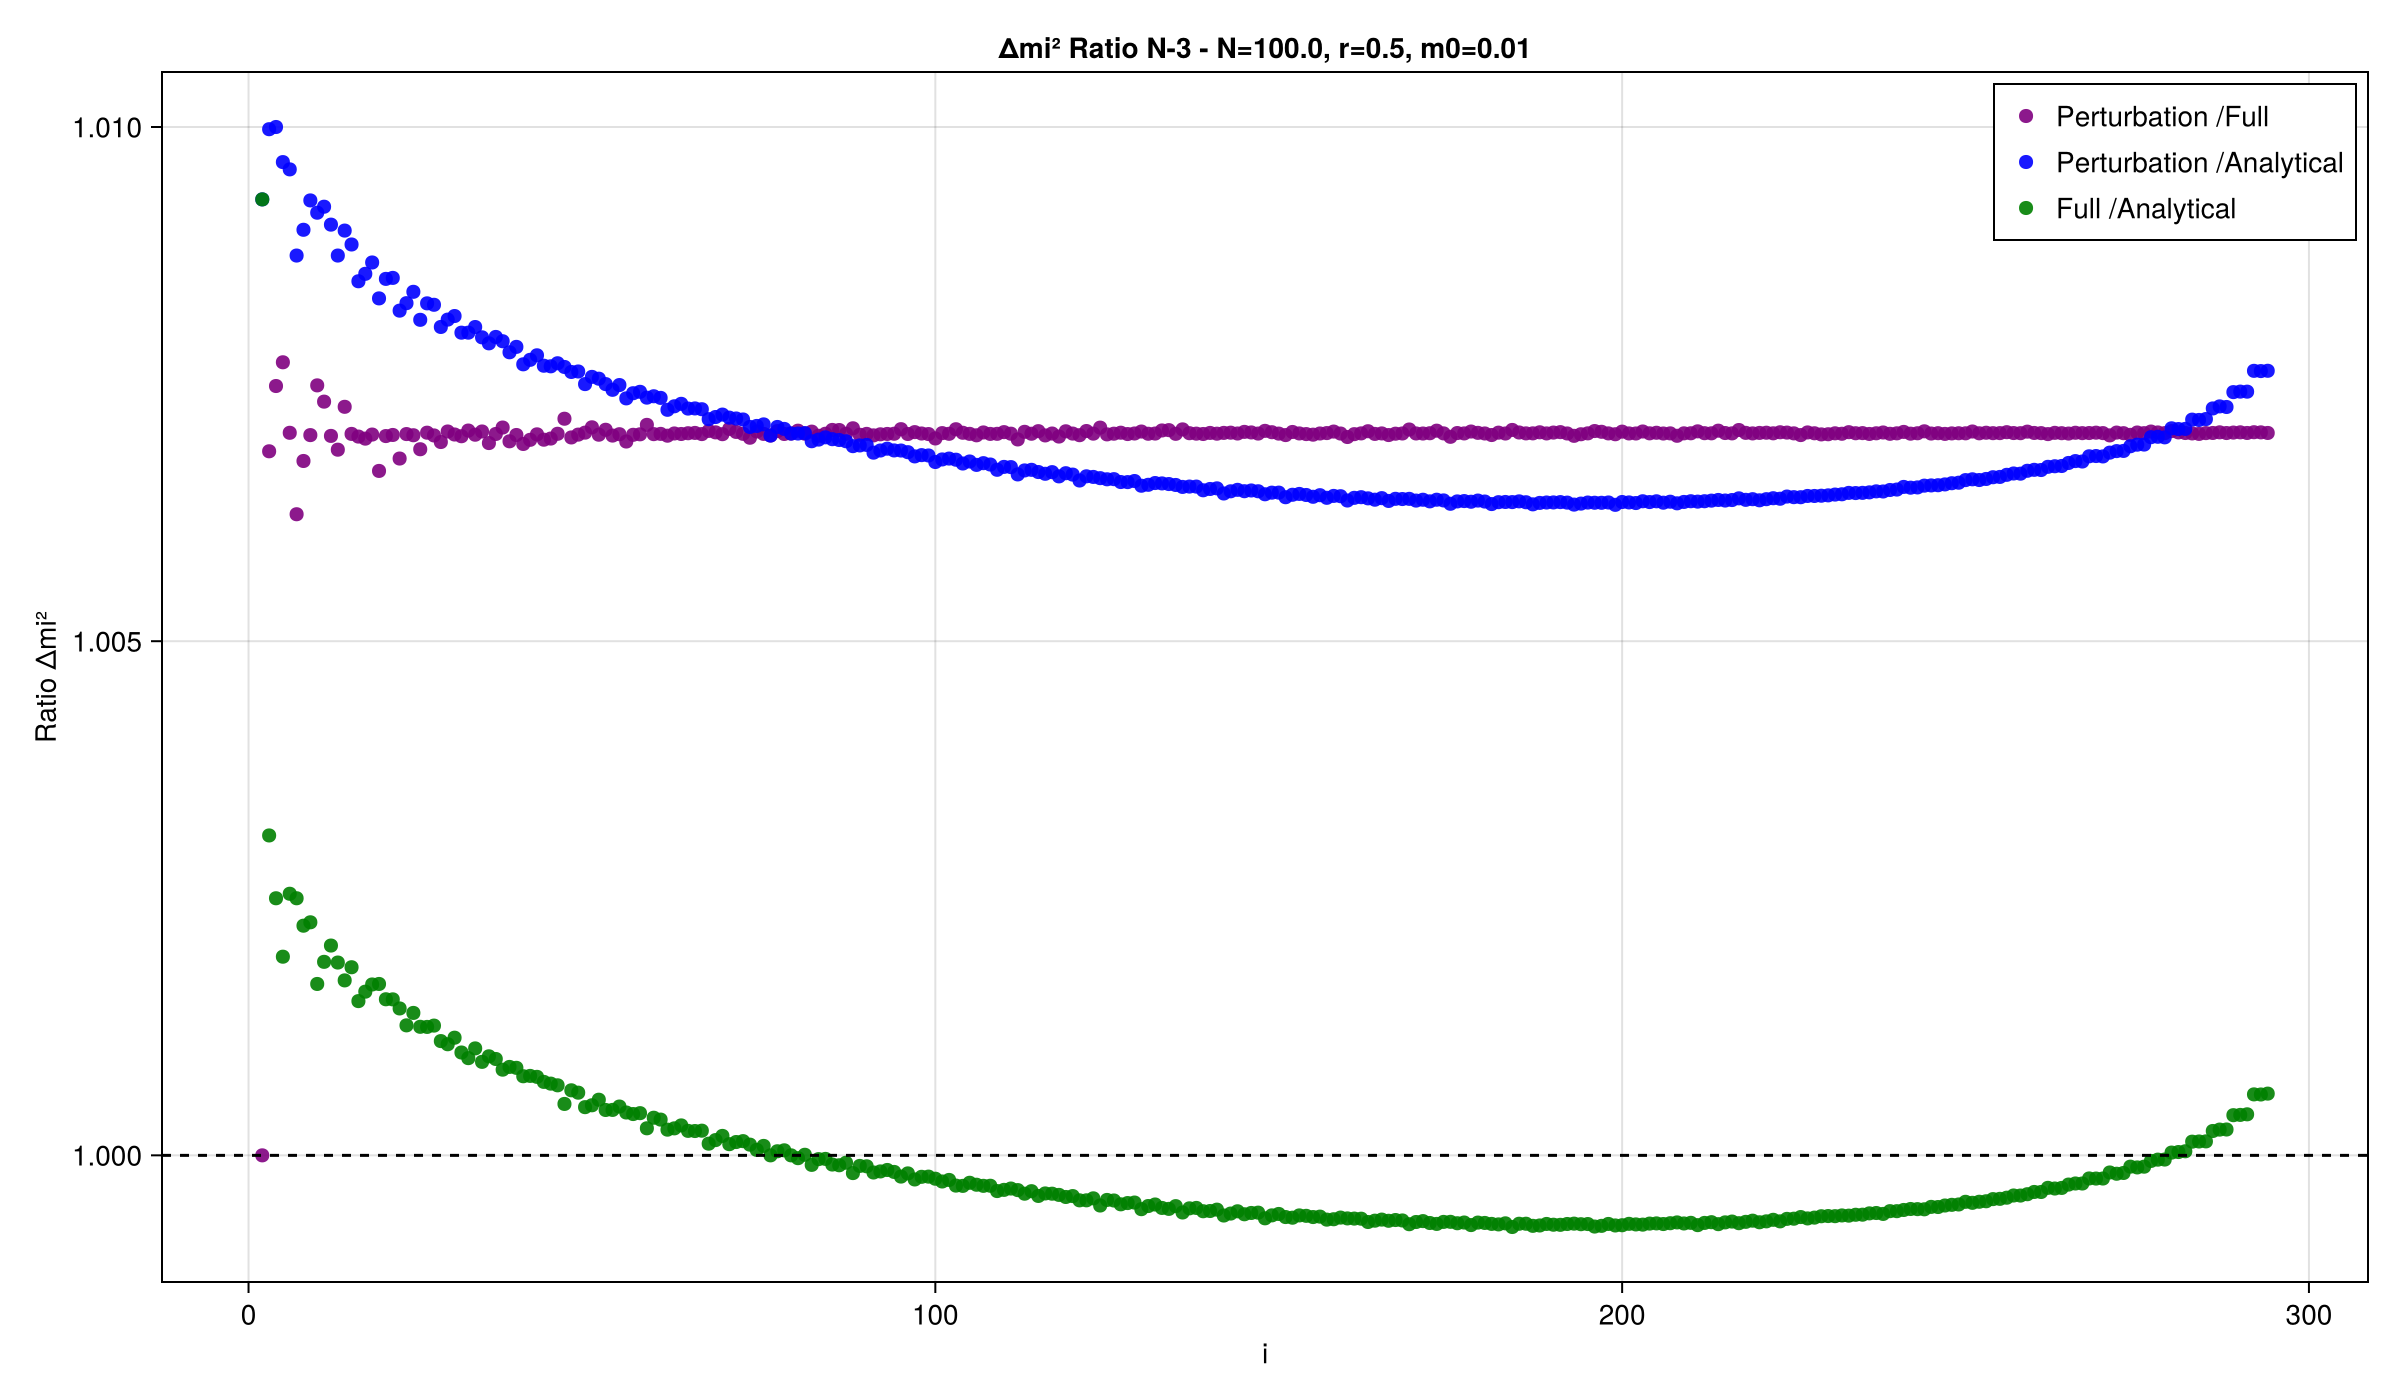

CairoMakie.Screen{IMAGE}


In [137]:



residues_1 = vec(((file1_h ./ file2_h) ))#./ file1) .* 100)
residues_2 = vec(((file1_h ./ h_analytical[1:end-3]) ))#./ file1) .* 100)
residues_3 = vec(((file2_h ./ h_analytical[1:end-3])) )#./ file2) .* 100)



# Create the plot
fig = Figure(size=(1200, 700))
ax = Axis(fig[1, 1],
    xlabel="i",
    ylabel="Ratio Δmi²",
    title="Δmi² Ratio N-3 - N=$N, r=$r, m0=$m0")

# Plot scatter points for each file with different colors

scatter!(ax, indices1[1:end-3], residues_1[1:end-3], label="Perturbation /Full", markersize=10, alpha=0.9, color=:purple)
scatter!(ax,  indices1[1:end-3], residues_2[1:end-3], label="Perturbation /Analytical", markersize=10, alpha=0.9, color=:blue)
scatter!(ax, indices2[1:end-3], residues_3[1:end-3], label="Full /Analytical", markersize=10, alpha=0.9, color=:green)
hlines!(ax, 1, color=:black, linestyle=:dash)

#ylims!(ax, -1e-4, 1e-4)
# Add legend
axislegend(ax, position=:rt)

# Save and display
save("/home/sofialon/Newtrinos.jl/plots_NP/pert_full/h_ratio_NND_NO_$N $r $m0.png", fig)
display(fig)
